# Phân đoạn ngữ nghĩa vùng lũ trên ảnh SAR Sentinel-1

## Mô hình: U-Net với encoder ResNet34 (khởi tạo trọng số từ ImageNet)

### Mục tiêu của notebook

Notebook này huấn luyện và đánh giá một mô hình học sâu cho bài toán **phân đoạn ngữ nghĩa nhị phân** (binary semantic segmentation): với mỗi pixel của ảnh radar khẩu độ tổng hợp (Synthetic Aperture Radar - SAR), mô hình dự đoán pixel đó thuộc vùng lũ (lớp 1) hay không thuộc vùng lũ (lớp 0). Đầu ra là một mặt nạ nhị phân có cùng kích thước với ảnh đầu vào, có thể được dùng để hỗ trợ công tác cảnh báo, đánh giá thiệt hại, và lập kế hoạch ứng phó lũ lụt.

### Vì sao chọn ảnh SAR thay vì ảnh quang học?

Ảnh quang học (như Sentinel-2, Landsat) ghi nhận ánh sáng phản xạ trong dải khả kiến và hồng ngoại. Tuy nhiên đối với bài toán lũ lụt, ảnh quang học có hai nhược điểm cố hữu:

- Bị mây che phủ hoàn toàn — mà lũ thường đi kèm thời tiết xấu, độ phủ mây cao.
- Không hoạt động được vào ban đêm.

Ngược lại, SAR thuộc vùng vi sóng (microwave). Cảm biến chủ động phát sóng và thu tín hiệu phản xạ trở về (backscatter), nhờ đó:

- Tín hiệu vi sóng xuyên được qua mây, mưa nhẹ.
- Cảm biến tự phát tín hiệu nên hoạt động được cả ngày lẫn đêm.
- Mặt nước phẳng có hiệu ứng tán xạ về phía trước (forward scattering), tức là tín hiệu radar bị phản xạ theo hướng lệch khỏi cảm biến → backscatter rất thấp → vùng nước biểu hiện rất tối trong ảnh SAR. Đây là dấu hiệu nhận biết then chốt cho phép tách nước khỏi đất khô.

Sentinel-1 cung cấp ảnh SAR ở hai kênh phân cực:

- **VV** (truyền dọc - thu dọc, co-polarization): phản xạ mạnh từ các bề mặt cứng theo cơ chế tán xạ mặt. Nước phẳng có giá trị VV thấp.
- **VH** (truyền dọc - thu ngang, cross-polarization): nhạy với tán xạ thể tích của tán lá cây, công trình. Nước phẳng có giá trị VH thấp hơn nữa, vì vậy VH thường là kênh nhạy với nước nhất.

Giá trị của hai kênh được lưu ở đơn vị **decibel (dB)** sau khi đã hiệu chỉnh bức xạ. Khoảng giá trị điển hình:

- Nước phẳng: VV khoảng -20 đến -15 dB, VH khoảng -25 đến -20 dB.
- Đất khô: VV và VH từ -15 đến -5 dB.
- Đô thị và công trình kim loại: có thể vượt 0 dB.

### Bộ dữ liệu Sen1Floods11

Sen1Floods11 (Bonafilia và cộng sự, CVPR Workshops 2020) là benchmark phổ biến nhất cho bài toán phân đoạn lũ từ Sentinel-1:

- **11 sự kiện lũ thực tế** trên 6 lục địa: Bolivia, Cambodia, Ghana, India, Mekong, Nigeria, Pakistan, Paraguay, Somalia, Spain, Sri Lanka, USA.
- **Hai tập con**:
  - `HandLabeled`: 446 chip 512×512 được chuyên gia gán nhãn thủ công, chất lượng cao, dùng cho val/test và một phần train.
  - `WeaklyLabeled`: 4.385 chip có nhãn tự động sinh từ chỉ số nước Sentinel-2 (S2 Index), nhãn có nhiễu nhưng số lượng lớn, dùng bổ sung cho train.
- **Quy ước nhãn ba giá trị** (do tác giả dataset định nghĩa):
  - `-1`: pixel không có dữ liệu hợp lệ (bị mây che ở ảnh quang học tham chiếu, hoặc lỗi cảm biến).
  - `0`: không phải nước.
  - `1`: nước (bao gồm nước lũ và nước thường nằm trong vùng lũ).

### Đường ống xử lý (pipeline)

Sơ đồ tổng thể tương ứng với các phần của notebook:

```
Ảnh vào (VV, VH)
    │
    ▼
Normalize:  clip giá trị dB về [-50, 0], rồi đưa về [0, 1]
    │
    ▼
Encoder (ResNet34, pretrained ImageNet):
    Trích xuất đặc trưng đa cấp (multi-scale)
    │
    ▼
Segmentation Head (U-Net decoder):
    Upsample + skip connection để khôi phục độ phân giải
    │
    ▼
Loss:  L = 0.5 * BCE + 0.5 * Dice
    │
    ▼
Evaluation:  IoU, F1, Precision, Recall, FAR, Risk
```

### Cấu hình thực thi tham chiếu

- Phần cứng tham chiếu: GPU NVIDIA có CUDA, VRAM tối thiểu 8 GB (RTX 3070, RTX 3070 Ti, T4 trên Kaggle/Colab).
- Mã nguồn sử dụng Automatic Mixed Precision (AMP) FP16, tiết kiệm khoảng 50% VRAM so với FP32 thuần.
- Với batch size 16 ở độ phân giải 256×256, thời gian một epoch ước tính 3-5 phút trên RTX 3070 Ti.
- Tổng thời gian huấn luyện ước tính 1-2 giờ, kết thúc sớm hơn nếu cơ chế early stopping kích hoạt.

### Tổ chức notebook

Mỗi phần dưới đây gồm một cell markdown giải thích chi tiết kỹ thuật được sử dụng, theo sau là một hoặc nhiều cell code thực thi. Người đọc có thể chạy lần lượt từ trên xuống.


## 1. Cài đặt thư viện và import

### Vai trò của từng nhóm thư viện

**Đọc và xử lý ảnh viễn thám**

- `rasterio`: thư viện chuẩn để đọc/ghi file GeoTIFF (`.tif`). Định dạng này thường dùng cho ảnh vệ tinh vì lưu được cả dữ liệu pixel lẫn metadata địa lý (hệ tọa độ tham chiếu CRS, geotransform). Các thư viện ảnh thông dụng như OpenCV hay Pillow không đọc được GeoTIFF dạng float đa kênh (như ảnh Sentinel-1 ở dB).

**Học sâu**

- `torch`, `torch.nn`, `torch.nn.functional`: framework PyTorch cung cấp tensor đa chiều, autograd (tính gradient tự động), và các layer mạng neural cơ bản.
- `torch.utils.data`: hai lớp chính là `Dataset` (đại diện một bộ dữ liệu) và `DataLoader` (iterator có shuffle, batch, multi-process).
- `torch.amp`: Automatic Mixed Precision, cho phép một số phép tính chạy ở FP16 thay vì FP32, vừa tiết kiệm bộ nhớ vừa tăng tốc trên GPU hỗ trợ Tensor Core (Volta trở lên).

**Mô hình phân đoạn**

- `segmentation_models_pytorch` (viết tắt `smp`): thư viện cung cấp sẵn các kiến trúc phân đoạn phổ biến (U-Net, FPN, DeepLabV3+, MAnet, PAN, LinkNet...) kèm hơn 100 encoder backbone (ResNet, EfficientNet, MobileNet, ResNeXt...). Sử dụng `smp` giúp tránh viết lại kiến trúc từ đầu, đồng thời tận dụng được trọng số pretrained ImageNet.

**Tăng cường dữ liệu và tiện ích**

- `albumentations`: thư viện augmentation rất nhanh (viết bằng OpenCV C++), hỗ trợ áp dụng cùng phép biến đổi cho `image`, `mask` và các target phụ (ví dụ valid mask). Quan trọng vì nếu lật ngang ảnh mà không lật ngang nhãn thì nhãn sẽ lệch.
- `tqdm`: thanh tiến trình cho vòng lặp huấn luyện, giúp ước lượng thời gian còn lại.
- `matplotlib`, `pandas`, `numpy`: trực quan hóa, xử lý dữ liệu dạng bảng, và tính toán mảng.

### Lưu ý khi cài đặt

Cell `pip install` đã được comment để không chạy lại nếu thư viện đã có sẵn. Trên môi trường mới (Kaggle, Colab, máy local lần đầu), bỏ comment dòng `pip install` và chạy.


In [1]:
# Bỏ comment nếu chưa cài
# !pip install -q segmentation-models-pytorch albumentations rasterio tqdm


In [2]:
import os
import gc
import csv
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import rasterio
from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import segmentation_models_pytorch as smp
import albumentations as A
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"smp    : {smp.__version__}")
print(f"album  : {A.__version__}")


PyTorch: 2.7.1+cu118
CUDA   : True
GPU    : NVIDIA GeForce RTX 3070 Ti
VRAM   : 8.0 GB
smp    : 0.5.0
album  : 2.0.8


## 2. Thiết lập đường dẫn dataset

### Cấu trúc thư mục Sen1Floods11

Sau khi tải về và giải nén, cấu trúc thư mục có dạng:

```
flood_events/
├── HandLabeled/
│   ├── S1Hand/          # Ảnh SAR Sentinel-1 (.tif, 2 kênh VV-VH)
│   ├── S2Hand/          # Ảnh quang học Sentinel-2 (.tif, 13 kênh, không dùng ở đây)
│   ├── LabelHand/       # Nhãn thủ công (.tif, 1 kênh, giá trị {-1, 0, 1})
│   ├── S1OtsuLabelHand/ # Nhãn tự động từ Otsu trên S1 (không dùng ở đây)
│   ├── S2IndexLabelHand/# Nhãn tự động từ chỉ số nước S2 (không dùng ở đây)
│   └── JRCWaterHand/    # Nhãn nước lịch sử JRC (không dùng ở đây)
└── WeaklyLabeled/
    ├── S1Weak/
    ├── S2Weak/
    ├── S1OtsuLabelWeak/
    └── S2IndexLabelWeak/ # Nhãn weak dùng cho train (tự động từ chỉ số S2)
```

Notebook này chỉ sử dụng bốn thư mục:

- `HandLabeled/S1Hand`: ảnh đầu vào tập có nhãn thủ công.
- `HandLabeled/LabelHand`: nhãn đối chiếu (ground truth) cho val/test và một phần train.
- `WeaklyLabeled/S1Weak`: ảnh đầu vào tập có nhãn yếu.
- `WeaklyLabeled/S2IndexLabelWeak`: nhãn yếu sinh tự động từ chỉ số nước Sentinel-2 (NDWI biến thể).

### Quy ước đặt tên file

Mỗi chip được định danh bằng cú pháp `{Country}_{ID}_{Suffix}.tif`, ví dụ:

- `Bolivia_103757_S1Hand.tif` → ảnh SAR của Bolivia, ID 103757, tập Hand.
- `Bolivia_103757_LabelHand.tif` → nhãn tương ứng, cùng `{Country}_{ID}` nhưng đổi suffix.

Quy tắc tìm nhãn từ ảnh: thay chuỗi `_S1Hand` bằng `_LabelHand` trong tên file.

### Hai cách trỏ đường dẫn

Có hai môi trường thực thi phổ biến:

- **Kaggle**: dataset được pull bằng `kagglehub.dataset_download`, trả về đường dẫn tự động vào `/root/.cache/kagglehub/...`. Tùy chọn này tiện khi chạy notebook trên Kaggle.
- **Local**: trỏ trực tiếp đến thư mục đã giải nén trên máy. Tùy chọn này nhanh hơn nếu đã có sẵn dataset trên ổ cứng.

Đoạn code dưới chọn một trong hai. Mặc định dùng local, đổi `BASE` cho phù hợp với máy.


In [3]:
# === Option A: Kaggle (giống flood-h3) ===
# import kagglehub
# BASE = kagglehub.dataset_download("robertomarinoformica/sen1floods11-dataset")

# === Option B: Local (nếu chạy máy cá nhân) ===
# Trỏ tới thư mục chứa 'HandLabeled/' và 'WeaklyLabeled/'
BASE = "data/sen1floods_local/sen1floods11/v1.1/data/flood_events"

S1_DIR   = os.path.join(BASE, "HandLabeled", "S1Hand")
LBL_DIR  = os.path.join(BASE, "HandLabeled", "LabelHand")
WEAK_S1  = os.path.join(BASE, "WeaklyLabeled", "S1Weak")
WEAK_LBL = os.path.join(BASE, "WeaklyLabeled", "S2IndexLabelWeak")

required_dirs = [S1_DIR, LBL_DIR, WEAK_S1, WEAK_LBL]
for d in required_dirs:
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Không tìm thấy {d}. Hãy chỉnh lại BASE cho đúng môi trường.")

print("Hand S1   :", S1_DIR)
print("Hand label:", LBL_DIR)
print("Weak S1   :", WEAK_S1)
print("Weak label:", WEAK_LBL)


Hand S1   : data/sen1floods_local/sen1floods11/v1.1/data/flood_events\HandLabeled\S1Hand
Hand label: data/sen1floods_local/sen1floods11/v1.1/data/flood_events\HandLabeled\LabelHand
Weak S1   : data/sen1floods_local/sen1floods11/v1.1/data/flood_events\WeaklyLabeled\S1Weak
Weak label: data/sen1floods_local/sen1floods11/v1.1/data/flood_events\WeaklyLabeled\S2IndexLabelWeak


## 3. Kiểm tra số lượng file

Trước khi xây dựng pipeline dữ liệu, ta kiểm tra số file trong mỗi thư mục để đảm bảo:

- Số chip Hand S1 và Hand label khớp nhau (mỗi ảnh phải có nhãn tương ứng).
- Số chip Weak S1 và Weak label khớp nhau.
- Không có file thiếu hoặc tên không đúng quy ước.

Đây là bước kiểm tra dữ liệu cơ bản (data sanity check) cần thiết cho mọi project học máy. Nếu số file lệch nhau, có thể dataset đã bị tải dở hoặc bị mất file.

Dataset Sen1Floods11 chuẩn có:

- Khoảng **446 chip HandLabeled** (chính xác có thể chênh ±5 do version dataset).
- Khoảng **4.385 chip WeaklyLabeled**.

Nếu số liệu in ra khớp xấp xỉ các con số trên, dữ liệu hợp lệ và có thể tiếp tục.


In [4]:
hand_s1_files  = sorted(f for f in os.listdir(S1_DIR)  if f.endswith("_S1Hand.tif"))
hand_lbl_files = sorted(f for f in os.listdir(LBL_DIR) if f.endswith("_LabelHand.tif"))
weak_s1_files  = sorted(f for f in os.listdir(WEAK_S1)  if f.endswith("_S1Weak.tif"))
weak_lbl_files = sorted(f for f in os.listdir(WEAK_LBL) if f.endswith("_S2IndexLabelWeak.tif"))

print(f"Hand S1 files    : {len(hand_s1_files)}")
print(f"Hand label files : {len(hand_lbl_files)}")
print(f"Weak S1 files    : {len(weak_s1_files)}")
print(f"Weak label files : {len(weak_lbl_files)}")
print(f"Hand samples     : {hand_s1_files[:3]}")


Hand S1 files    : 446
Hand label files : 446
Weak S1 files    : 4384
Weak label files : 4384
Hand samples     : ['Bolivia_103757_S1Hand.tif', 'Bolivia_129334_S1Hand.tif', 'Bolivia_195474_S1Hand.tif']


## 4. Chia tập train, validation, test

### Vấn đề rò rỉ dữ liệu (data leakage)

Cách chia tập "ngây thơ" nhất là shuffle ngẫu nhiên rồi cắt 80/10/10. Cách này **không phù hợp** với dataset có cấu trúc theo nhóm như Sen1Floods11, lý do:

Các chip trong cùng một sự kiện lũ (cùng quốc gia, cùng ngày chụp) thường:

- Cùng địa hình, cùng loại đất, cùng kiểu công trình.
- Cùng góc nhìn vệ tinh (incidence angle), cùng cấu hình quỹ đạo (ascending/descending).
- Cùng đặc điểm khí tượng, cùng độ ẩm đất tại thời điểm chụp.

Nếu chia ngẫu nhiên, các chip "anh em" này lọt vào cả train và test → mô hình "nhớ" đặc trưng địa phương của sự kiện → kết quả test cao giả tạo, không phản ánh khả năng tổng quát hóa thực tế của mô hình.

### Chiến lược chia theo nhóm (group split)

Để tránh rò rỉ, ta áp dụng quy tắc: **tất cả chip thuộc cùng một quốc gia phải nằm trong cùng một tập** (train, val, hoặc test). Cụ thể:

- **Test set**: chọn cố định ba quốc gia `{Bolivia, Ghana, USA}` làm test hold-out.
  - Đây là ba quốc gia có địa hình khác biệt: Bolivia thuộc vùng nhiệt đới Nam Mỹ với đồng bằng ngập, Ghana thuộc Tây Phi với đồng cỏ và đô thị, USA chứa các sự kiện lũ ven sông và ven biển.
  - Việc cố định danh sách (thay vì random) cho phép so sánh các thí nghiệm khác nhau trên cùng test set, đảm bảo reproducibility.
- **Validation set**: lấy ngẫu nhiên 20% từ các chip Hand còn lại (không thuộc test).
- **Train set**: gồm 80% Hand còn lại + toàn bộ Weak labels có quốc gia không nằm trong test.
  - Weak labels của Bolivia/Ghana/USA bị loại bỏ để tránh leak.
  - Seed `random=42` cố định để chia ổn định qua các lần chạy.

### Hệ quả của cách chia này

- Mô hình huấn luyện trên **8 quốc gia**: Cambodia, India, Mekong, Nigeria, Pakistan, Paraguay, Somalia, Spain, Sri Lanka (trừ 3 quốc gia test).
- Đánh giá khả năng tổng quát hóa **sang quốc gia chưa từng thấy** (cross-region generalization).
- Đây là bài toán khó hơn so với chia ngẫu nhiên, nhưng phản ánh đúng tình huống thực tế: triển khai mô hình vào một sự kiện lũ mới ở khu vực chưa có dữ liệu huấn luyện.

### Cách trích quốc gia từ tên file

Tên file có dạng `{Country}_{ID}_{Suffix}.tif`. Ta tách bằng cách split chuỗi tại dấu `_` và lấy phần tử đầu tiên:

- `Bolivia_103757_S1Hand.tif` → `Country = "Bolivia"`.
- `Ghana_597288_S1Hand.tif` → `Country = "Ghana"`.

Hàm `chip_group(name)` thực hiện việc này.


In [5]:
def chip_name(filename, suffix):
    return filename.replace(suffix, "")

def chip_group(name):
    return name.split("_")[0]

hand_chips     = [chip_name(f, "_S1Hand.tif") for f in hand_s1_files]
weak_chips_all = [chip_name(f, "_S1Weak.tif") for f in weak_s1_files]

# Split đúng giống flood-h3 để fair comparison
TEST_GROUPS = {'Bolivia', 'Ghana', 'USA'}
test_chips  = sorted(c for c in hand_chips if chip_group(c) in TEST_GROUPS)

non_test = [c for c in hand_chips if chip_group(c) not in TEST_GROUPS]
random.seed(42)
random.shuffle(non_test)
n_val       = int(len(non_test) * 0.2)
val_chips   = non_test[:n_val]
train_chips = non_test[n_val:]

weak_train = [c for c in weak_chips_all if chip_group(c) not in TEST_GROUPS]

print(f"Test      : {len(test_chips)} chip")
print(f"Val       : {len(val_chips)} chip")
print(f"Train hand: {len(train_chips)} chip")
print(f"Train weak: {len(weak_train)} chip")
print(f"Train tổng: {len(train_chips) + len(weak_train)} chip")


Test      : 137 chip
Val       : 61 chip
Train hand: 248 chip
Train weak: 3493 chip
Train tổng: 3741 chip


## 5. Chuyển đổi TIF sang NPY (cache)

### Vì sao cần cache?

Mỗi epoch train sẽ duyệt qua toàn bộ chip nhiều lần. Đọc file `.tif` bằng `rasterio` có overhead lớn vì:

- `rasterio` phải parse metadata GeoTIFF (CRS, geotransform, mô tả band) mỗi lần mở.
- Phải decode dữ liệu nén từ disk vào RAM.
- Mỗi lần mở file là một system call, chậm đặc biệt trên ổ HDD và NFS.

Đọc bằng `numpy.load` thì:

- Không có metadata phụ, chỉ là một mảng `ndarray` raw.
- Bố cục bộ nhớ liên tục (contiguous memory layout) nên giải mã rất nhanh.

Thử nghiệm thực tế cho thấy đọc `.npy` nhanh hơn `.tif` từ 10 đến 20 lần. Với batch size 16, mỗi step phải load 16 file: tiết kiệm này tích lũy đáng kể qua hàng nghìn step.

### Chiến lược cache

- Lần đầu chạy: đọc từng file `.tif`, giải mã, lưu thành `.npy` trong thư mục `cache/`.
- Các lần chạy sau: chỉ cần đọc `.npy`. Nếu file `.npy` đã tồn tại, bỏ qua không convert lại.

### Kiểu dữ liệu

- Ảnh SAR (`s1_hand`, `s1_weak`): `float32`, shape `(2, 512, 512)`. Đơn vị dB, giá trị âm.
- Nhãn (`lbl_hand`, `lbl_weak`): `int16`, shape `(512, 512)`. Giá trị thuộc `{-1, 0, 1}`.

Dùng `int16` cho nhãn (thay vì `int64` mặc định) để tiết kiệm dung lượng đĩa: nhãn chỉ có 3 giá trị nên 16 bit là dư.

### Dung lượng cache ước tính

- Hand: 446 chip × (2 + 1) × 512 × 512 × bytes ≈ 700 MB.
- Weak: 4.385 chip × tương tự ≈ 7 GB.
- Tổng khoảng 7.5-8 GB. Cần đảm bảo ổ đĩa đủ chỗ.

### Vị trí cache

Nếu chạy trên Kaggle, dùng `/kaggle/working/cache`. Nếu chạy local, dùng `cache/` ở thư mục hiện hành.


In [6]:
# Thư mục cache: dùng chung với flood-h3 (đỡ phải convert 2 lần)
CACHE = '/kaggle/working/cache' if os.path.isdir('/kaggle/working') else 'cache'
for d in ['s1_hand','lbl_hand','s1_weak','lbl_weak']:
    os.makedirs(f'{CACHE}/{d}', exist_ok=True)

print(f"Cache dir: {CACHE}")

print("\nConverting HandLabeled...")
for chip in tqdm(os.listdir(S1_DIR), desc='Hand'):
    name = chip.replace('_S1Hand.tif', '')
    npy_s1  = f'{CACHE}/s1_hand/{name}.npy'
    npy_lbl = f'{CACHE}/lbl_hand/{name}.npy'
    if not os.path.exists(npy_s1):
        with rasterio.open(f'{S1_DIR}/{chip}') as f:
            np.save(npy_s1, f.read().astype(np.float32))
    if not os.path.exists(npy_lbl):
        with rasterio.open(f'{LBL_DIR}/{name}_LabelHand.tif') as f:
            np.save(npy_lbl, f.read(1).astype(np.int16))

print("Converting WeaklyLabeled...")
for chip in tqdm(os.listdir(WEAK_S1), desc='Weak'):
    name = chip.replace('_S1Weak.tif', '')
    npy_s1  = f'{CACHE}/s1_weak/{name}.npy'
    npy_lbl = f'{CACHE}/lbl_weak/{name}.npy'
    if not os.path.exists(npy_s1):
        with rasterio.open(f'{WEAK_S1}/{chip}') as f:
            np.save(npy_s1, f.read().astype(np.float32))
    if not os.path.exists(npy_lbl):
        with rasterio.open(f'{WEAK_LBL}/{name}_S2IndexLabelWeak.tif') as f:
            np.save(npy_lbl, f.read(1).astype(np.int16))

print("Cache done!")


Cache dir: cache

Converting HandLabeled...


Hand:   0%|          | 0/446 [00:00<?, ?it/s]

Converting WeaklyLabeled...


Weak:   0%|          | 0/4384 [00:00<?, ?it/s]

Cache done!


## 6. Trực quan hóa bộ dữ liệu

### Mục đích

Trước khi train, ta cần nhìn trực tiếp vài chip để:

- Xác nhận rằng giá trị pixel nằm trong khoảng dB hợp lý (khoảng -50 đến 0).
- Kiểm tra rằng nhãn (label) đúng cấu trúc {-1, 0, 1}.
- Quan sát đặc điểm trực quan: nước trong VH có thực sự tối hơn nền không, vùng nào dễ nhầm với nước, tỷ lệ nước/đất trong từng chip ra sao.
- Phát hiện các chip có nhiều pixel invalid (mây dày, lỗi cảm biến) nếu có.

### Cách hiển thị từng thành phần

**VV và VH** (cột 1 và 2): hiển thị dạng grayscale. Vì giá trị dB nằm trong khoảng âm, ta dùng phép biến đổi trực quan:

$$x_{disp} = \frac{\text{clip}(x, -50, 0) + 50}{50}$$

Phép biến đổi này đưa `-50 dB → 0` (đen) và `0 dB → 1` (trắng), giúp mắt người quan sát phân biệt được vùng có giá trị thấp (nước, tối) với vùng có giá trị cao (đô thị, sáng).

**Label** (cột 3): dùng một colormap ba màu:

- Xám (gray) cho pixel invalid `-1`.
- Đen (black) cho lớp background `0` (không phải nước).
- Đỏ (red) cho lớp flood `1` (nước/lũ).

Phía trên mỗi chip, ta in:
- `flood=X%`: tỷ lệ pixel là nước trong số pixel hợp lệ.
- `inv=Y%`: tỷ lệ pixel invalid (không có nhãn).

Tỷ lệ flood cho biết mức độ mất cân bằng lớp (class imbalance). Trong Sen1Floods11, đa số chip có dưới 30% là nước, một số chip gần như toàn nước, một số chip không có nước. Sự đa dạng này phản ánh thực tế: vệ tinh chụp cả vùng bị ngập lẫn vùng lân cận khô.

### Lưu ý về cân bằng lớp

Trong segmentation, class imbalance ảnh hưởng đến lựa chọn hàm mất mát và chiến lược đánh giá:

- Nếu nền (background) chiếm đa số, hàm BCE thuần có xu hướng đẩy mô hình về dự đoán "tất cả là nền" để có loss thấp.
- Hàm Dice giảm thiểu vấn đề này vì nó tối ưu trực tiếp overlap vùng nước.

Đây là một trong những lý do ta kết hợp BCE và Dice trong phần 12.


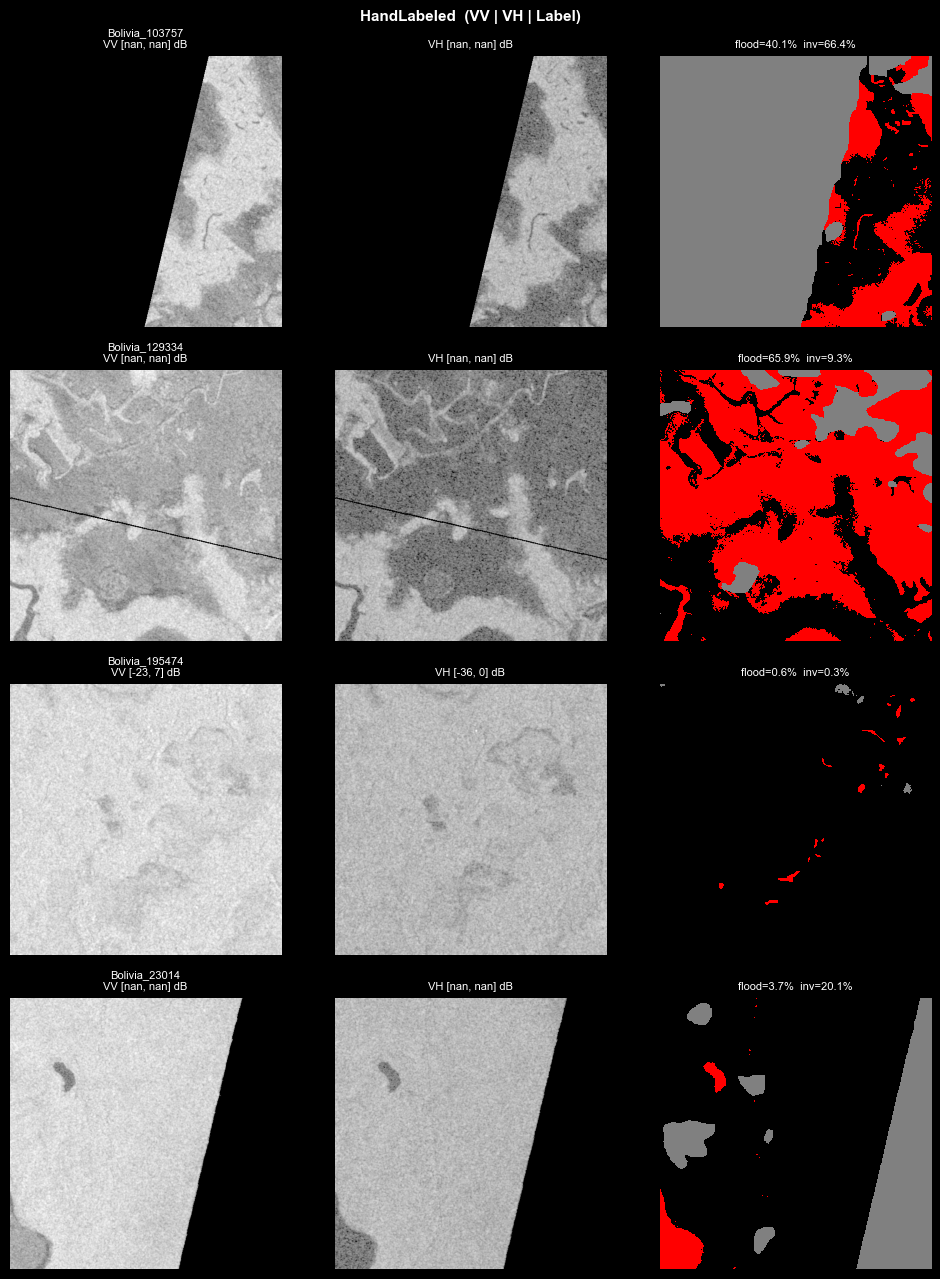

Legend: grey=invalid(-1)  black=background(0)  red=flood(1)


In [7]:
lbl_cmap = ListedColormap(['gray', 'black', 'red'])  # 0=invalid, 1=bg, 2=flood

def show_chip(ax_vv, ax_vh, ax_lbl, name, s1_dir, lbl_dir, title=''):
    s1  = np.load(f'{s1_dir}/{name}.npy')
    lbl = np.load(f'{lbl_dir}/{name}.npy')
    vv = s1[0]; vh = s1[1]
    vv_disp = (np.clip(vv, -50, 0) + 50) / 50
    vh_disp = (np.clip(vh, -50, 0) + 50) / 50

    ax_vv.imshow(vv_disp, cmap='gray', vmin=0, vmax=1)
    ax_vv.set_title(title + '\nVV [%.0f, %.0f] dB' % (vv.min(), vv.max()), fontsize=8)
    ax_vv.axis('off')

    ax_vh.imshow(vh_disp, cmap='gray', vmin=0, vmax=1)
    ax_vh.set_title('VH [%.0f, %.0f] dB' % (vh.min(), vh.max()), fontsize=8)
    ax_vh.axis('off')

    lbl_shifted = lbl.astype(np.int16) + 1
    ax_lbl.imshow(lbl_shifted, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
    flood_pct = 100 * (lbl == 1).sum() / max((lbl != -1).sum(), 1)
    inv_pct   = 100 * (lbl == -1).sum() / lbl.size
    ax_lbl.set_title('flood=%.1f%%  inv=%.1f%%' % (flood_pct, inv_pct), fontsize=8)
    ax_lbl.axis('off')

# 4 HandLabeled chips
hand_files = sorted(os.listdir(f'{CACHE}/s1_hand'))[:4]
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
fig.suptitle('HandLabeled  (VV | VH | Label)', fontsize=11, fontweight='bold')
for i, fname in enumerate(hand_files):
    name = fname.replace('.npy', '')
    show_chip(axes[i,0], axes[i,1], axes[i,2],
              name, f'{CACHE}/s1_hand', f'{CACHE}/lbl_hand', title=name)
plt.tight_layout(); plt.show()

print('Legend: grey=invalid(-1)  black=background(0)  red=flood(1)')


## 7. Cấu hình huấn luyện

### Tổng quan các nhóm hyperparameter

Tất cả tham số huấn luyện được gom vào một dictionary `CFG` duy nhất. Điều này giúp:

- Dễ điều chỉnh ở một chỗ duy nhất.
- Dễ in/log toàn bộ cấu hình ra file để truy vết về sau.
- Dễ tạo các biến thể thí nghiệm (chỉ cần copy CFG và chỉnh vài key).

### Giải thích từng nhóm tham số

**Nhóm dữ liệu**

- `crop_size = 256`: kích thước crop ngẫu nhiên khi train. Crop từ chip 512×512 xuống 256×256 có hai lợi ích:
  - Tăng đa dạng (một chip 512 có thể cho 4 crop 256 không chồng lấp).
  - Giảm bộ nhớ GPU cho phép tăng batch size.
- `batch_size = 16`: số sample mỗi lần forward/backward. Batch lớn cho gradient ổn định hơn nhưng tốn bộ nhớ. Với 256×256 và FP16 trên RTX 3070 Ti, batch 16 vừa khít.
- `num_workers = 2`: số process song song để load data. Tăng giúp pipeline không bị bottleneck CPU, nhưng cũng tăng RAM tiêu thụ.

**Nhóm huấn luyện**

- `lr = 1e-4`: learning rate ban đầu. Với optimizer AdamW + encoder pretrained ImageNet, lr này không quá lớn để phá trọng số pretrained nhưng đủ để decoder học từ đầu.
- `weight_decay = 1e-4`: hệ số L2 regularization, giảm overfitting bằng cách phạt trọng số có magnitude lớn.
- `epochs = 50`: số epoch tối đa. Thực tế thường dừng sớm hơn do early stopping.
- `early_stop = 10`: dừng nếu IoU validation không cải thiện trong 10 epoch liên tiếp.
- `grad_clip = 1.0`: cắt norm gradient ở 1.0 để tránh exploding gradient (đặc biệt khi mixed precision).

**Nhóm hàm mất mát**

- `bce_weight = 0.5`, `dice_weight = 0.5`: hệ số kết hợp BCE và Dice trong tổng loss.

  $$\mathcal{L}_{total} = 0.5 \cdot \mathcal{L}_{BCE} + 0.5 \cdot \mathcal{L}_{Dice}$$

  Tỷ lệ 50/50 là lựa chọn cân bằng phổ biến, không thiên về tối ưu pixel-wise (BCE) hay region-wise (Dice).

**Nhóm sample weighting**

- `hand_weight = 1.0`, `weak_weight = 1.0`: trọng số khi tính loss cho mẫu Hand và Weak. Cả hai bằng 1.0 nghĩa là không phân biệt độ tin cậy của nhãn.

**Nhóm threshold dự đoán**

- `pred_threshold = 0.5`: ngưỡng để biến xác suất sigmoid thành nhãn nhị phân. Mặc định 0.5 là ngưỡng "công bằng".


In [8]:
CFG = {
    # --- Data ---
    'crop_size'    : 256,
    'batch_size'   : 16,
    'num_workers'  : 2,
    
    # --- Training ---
    'lr'           : 1e-4,
    'weight_decay' : 1e-4,
    'epochs'       : 50,
    'early_stop'   : 10,
    'grad_clip'    : 1.0,
    
    # --- Loss BASELINE (đơn giản, 50/50) ---
    'bce_weight'   : 0.5,             # chuẩn 50/50, không phải 0.3 như flood-h3
    'dice_weight'  : 0.5,
    
    # --- Sample weighting BASELINE (đồng đều, không quality-aware) ---
    'hand_weight'  : 1.0,             # Cả Hand và Weak đều = 1.0
    'weak_weight'  : 1.0,
    
    # --- Threshold (cố định) ---
    'pred_threshold': 0.5,            # đơn giản, không tune phức tạp
    
    # --- Paths ---
    'checkpoint'   : 'best_unet.pth',
    'device'       : 'cuda' if torch.cuda.is_available() else 'cpu',
    'output_dir'   : 'outputs',
}

# Tạo folder output
Path(CFG['output_dir']).mkdir(exist_ok=True, parents=True)
Path(CFG['output_dir'], 'logs').mkdir(exist_ok=True)
Path(CFG['output_dir'], 'figures').mkdir(exist_ok=True)
Path(CFG['output_dir'], 'checkpoints').mkdir(exist_ok=True)

# Fix seed
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
set_seed(42)

print("Device:", CFG["device"])
print("Output:", CFG['output_dir'])


Device: cuda
Output: outputs


## 8. Lớp Dataset

### Vai trò của lớp Dataset trong PyTorch

`torch.utils.data.Dataset` là lớp trừu tượng định nghĩa cách truy cập một mẫu dữ liệu. Cần implement hai phương thức:

- `__len__()`: trả về số mẫu trong tập.
- `__getitem__(idx)`: trả về mẫu thứ `idx` dưới dạng tensor.

`DataLoader` sau đó tự động gom các mẫu thành batch và song song hóa qua nhiều worker process.

### Các bước trong `__getitem__`

**Bước 1: Đọc ảnh và nhãn từ file `.npy`**

```python
s1  = np.load(f'{self.s1_dir}/{name}.npy')   # (2, 512, 512) float32 đơn vị dB
lbl = np.load(f'{self.lbl_dir}/{name}.npy')  # (512, 512) int16
```

**Bước 2: Xử lý giá trị bất thường (NaN, Inf)**

```python
s1 = np.nan_to_num(s1, nan=-50.0, posinf=0.0, neginf=-50.0)
```

Một số chip Sentinel-1 có pixel NaN ở rìa scene (do quá trình ghép quỹ đạo). Nếu để NaN đi qua mạng, gradient sẽ thành NaN và toàn bộ training hỏng. Hàm `nan_to_num` thay NaN bằng `-50.0` (sàn dB), `+Inf` bằng `0.0`, và `-Inf` bằng `-50.0`.

**Bước 3: Chuẩn hóa dB về [0, 1]**

Đây chính là khâu **Normalize** trong sơ đồ pipeline. Công thức:

$$x_{norm} = \frac{\text{clip}(x, -50, 0) + 50}{50}$$

Diễn giải:

- `clip(x, -50, 0)`: cắt giá trị về khoảng [-50, 0] dB. Hơn 99% giá trị thực tế của Sentinel-1 nằm trong khoảng này, các giá trị ngoài thường là artifact của cảm biến.
- `+ 50` rồi `/ 50`: đưa về [0, 1] tuyến tính. `-50 dB → 0.0`, `0 dB → 1.0`.

Vì sao chuẩn hóa về [0, 1]?

- Các layer Conv ban đầu của ResNet được pretrain trên ảnh RGB có giá trị trong khoảng [0, 1] (sau khi chia 255). Đưa SAR về cùng khoảng giúp tận dụng tốt hơn trọng số pretrained.
- Tránh giá trị âm gây bất ổn cho BatchNorm ở những layer đầu.
- Tránh giá trị quá lớn gây overflow trong FP16 (AMP).

**Bước 4: Tách valid mask**

```python
valid = (lbl != -1).astype(np.uint8)
lbl   = np.clip(lbl, 0, 1).astype(np.uint8)
```

Sau bước này:

- `valid`: mask boolean cho biết pixel nào có nhãn hợp lệ.
- `lbl`: nhãn nhị phân `{0, 1}`. Pixel invalid được set về `0` để tránh giá trị âm gây lỗi loss, nhưng `valid` mask vẫn ghi nhớ chúng để loss sau này biết bỏ qua.

**Bước 5: Áp dụng augmentation (chỉ khi train)**

Albumentations làm việc với layout `(H, W, C)` của ảnh chứ không phải `(C, H, W)` của PyTorch, nên ta transpose tạm thời:

```python
s1_hwc = s1.transpose(1, 2, 0)
out    = self.transform(image=s1_hwc, mask=lbl, valid=valid)
```

Hàm transform được khai báo với `additional_targets={'valid': 'mask'}` để albumentations áp dụng cùng phép biến đổi cho cả ba (ảnh, mask, valid). Nếu lật ngang ảnh mà không lật mask thì nhãn sẽ lệch.

**Bước 6: Chuyển về tensor PyTorch**

Transpose ngược về `(C, H, W)` và đưa vào `torch.tensor`:

```python
s1_t    = torch.from_numpy(s1_hwc.transpose(2, 0, 1).copy()).float()
lbl_t   = torch.from_numpy(lbl.copy()).long()
valid_t = torch.from_numpy(valid.copy()).bool()
```

Trả về tuple `(s1_t, lbl_t, valid_t, sw)`:

- `s1_t`: tensor float32 shape `(2, H, W)`, dải [0, 1].
- `lbl_t`: tensor int64 shape `(H, W)`, giá trị {0, 1}.
- `valid_t`: tensor bool shape `(H, W)`, `True` nếu pixel hợp lệ.
- `sw`: sample weight (vô hướng), mặc định 1.0 cho cả Hand và Weak trong cấu hình hiện tại.


In [9]:
class FloodDataset(Dataset):
    def __init__(self, chips, is_hand=True, transform=None):
        self.chips     = chips
        self.is_hand   = is_hand
        self.transform = transform
        self.sw        = CFG['hand_weight'] if is_hand else CFG['weak_weight']
        self.s1_dir    = f'{CACHE}/s1_hand'  if is_hand else f'{CACHE}/s1_weak'
        self.lbl_dir   = f'{CACHE}/lbl_hand' if is_hand else f'{CACHE}/lbl_weak'

    def __len__(self):
        return len(self.chips)

    def __getitem__(self, idx):
        name = self.chips[idx]
        s1   = np.load(f'{self.s1_dir}/{name}.npy').astype(np.float32)
        lbl  = np.load(f'{self.lbl_dir}/{name}.npy').astype(np.int16)

        # Normalize: clip(-50, 0) -> [0, 1]
        s1 = np.nan_to_num(s1, nan=-50.0, posinf=0.0, neginf=-50.0)
        s1 = (np.clip(s1, -50.0, 0.0) + 50.0) / 50.0
        s1 = s1.astype(np.float32)

        # Valid mask + binary label
        valid = (lbl != -1).astype(np.uint8)
        lbl   = np.clip(lbl, 0, 1).astype(np.uint8)

        # Albumentations (HWC)
        s1_hwc = s1.transpose(1, 2, 0)
        if self.transform is not None:
            out    = self.transform(image=s1_hwc, mask=lbl, valid=valid)
            s1_hwc = out['image']
            lbl    = out['mask']
            valid  = out['valid']

        s1_t    = torch.from_numpy(s1_hwc.transpose(2, 0, 1).copy()).float()
        lbl_t   = torch.from_numpy(lbl.copy()).long()
        valid_t = torch.from_numpy(valid.copy()).bool()
        return s1_t, lbl_t, valid_t, self.sw

# Test
ds_demo = FloodDataset(train_chips[:2], is_hand=True)
s1_t, lbl_t, valid_t, sw = ds_demo[0]
print(f"s1   : {tuple(s1_t.shape)} {s1_t.dtype} range=[{s1_t.min():.3f}, {s1_t.max():.3f}]")
print(f"lbl  : {tuple(lbl_t.shape)} {lbl_t.dtype} unique={torch.unique(lbl_t).tolist()}")
print(f"valid: {tuple(valid_t.shape)} {valid_t.dtype}")
print(f"sw   : {sw}  (baseline dùng 1.0 cho cả Hand và Weak)")


s1   : (2, 512, 512) torch.float32 range=[0.000, 1.000]
lbl  : (512, 512) torch.int64 unique=[0, 1]
valid: (512, 512) torch.bool
sw   : 1.0  (baseline dùng 1.0 cho cả Hand và Weak)


## 9. Augmentation (tăng cường dữ liệu)

### Vì sao cần augmentation?

Tập Hand có 446 chip, sau khi tách test còn lại khoảng 250-300 chip để train. Với một mạng có 21 triệu tham số như ResNet34 + U-Net, số lượng này rất ít, dễ dẫn đến overfitting (mạng học thuộc lòng từng chip mà không tổng quát hóa được).

Augmentation giải quyết bằng cách tạo ra các biến thể của mỗi chip qua các phép biến đổi giả lập. Mỗi epoch, cùng một chip có thể được nhìn dưới nhiều "góc nhìn" khác nhau, làm số mẫu thực tế mà mạng thấy tăng lên hàng chục lần.

### Augmentation đã chọn

Notebook chỉ dùng các phép biến đổi **hình học cơ bản** an toàn cho ảnh SAR:

**RandomCrop 256×256**

Cắt ngẫu nhiên một vùng 256×256 từ chip gốc 512×512.

- Tăng đa dạng: mỗi chip có thể cho khoảng $(512-256)^2 = 65536$ vị trí crop khác nhau (chồng lấp).
- Giảm bộ nhớ GPU: cho phép tăng batch size hoặc dùng mạng sâu hơn.
- Mất chút context toàn cục so với train full 512×512, nhưng đổi lại được đa dạng và batch lớn.

**HorizontalFlip (p=0.5)**

Lật ảnh theo trục dọc với xác suất 50%. Ảnh SAR không có "hướng" cố định như ảnh đời thường (mặt người, chữ viết), nên lật ngang không phá ý nghĩa.

**VerticalFlip (p=0.5)**

Lật ảnh theo trục ngang. Cũng an toàn cho SAR vì không có khái niệm "trên/dưới" cố định trong cảnh viễn thám.

**RandomRotate90 (p=0.5)**

Xoay 0°, 90°, 180°, hoặc 270° (mỗi góc 25%). Khác với xoay góc bất kỳ (cần interpolation, làm mờ ảnh), xoay 90° chỉ là hoán vị các trục nên không làm mờ và không sinh pixel "ảo".

### Augmentation đã không dùng

Một số augmentation phổ biến cho ảnh tự nhiên không được dùng ở đây:

- **Color jitter / Brightness contrast**: thay đổi cường độ một cách bất thường có thể phá tính chất vật lý của tín hiệu SAR (giá trị dB phản ánh tán xạ vật lý cụ thể).
- **Random rotation 1° đến 89°**: cần interpolation, làm mờ ranh giới water/land vốn đã không sắc nét trong SAR.
- **Cutout / random erase**: che một vùng bằng giá trị 0 có thể bị mạng nhầm là vùng nước (vì 0 trong [0,1] tương ứng -50 dB, rất thấp).
- **Mixup / CutMix**: trộn hai ảnh khác nhau có thể tạo ra cảnh không thực tế và làm mạng học sai phân phối.

Tham số `p=0.5` nghĩa là mỗi phép có 50% xác suất được áp dụng cho mỗi sample, độc lập với nhau.

### Augmentation cho validation/test

`val_tf` chỉ có `CenterCrop(256, 256)` để đảm bảo:

- Kích thước nhất quán với train (256×256).
- Không có ngẫu nhiên: cùng một chip luôn cho cùng một crop, để kết quả đánh giá ổn định qua các epoch.


In [10]:
train_tf = A.Compose([
    A.RandomCrop(CFG['crop_size'], CFG['crop_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # ⭐ KHÔNG có RandomBrightnessContrast (SAR radiometric jitter)
    # ⭐ KHÔNG có GaussNoise (speckle simulation)
], additional_targets={'valid': 'mask'})

val_tf = A.Compose([
    A.CenterCrop(CFG['crop_size'], CFG['crop_size']),
], additional_targets={'valid': 'mask'})

print("Train aug:")
for t in train_tf.transforms:
    print(f"  - {t.__class__.__name__}(p={t.p})")
print("Val aug: CenterCrop only")


Train aug:
  - RandomCrop(p=1.0)
  - HorizontalFlip(p=0.5)
  - VerticalFlip(p=0.5)
  - RandomRotate90(p=0.5)
Val aug: CenterCrop only


## 10. Tạo DataLoader

### Vai trò của DataLoader

`DataLoader` đảm nhiệm:

- Gom các sample đơn lẻ từ Dataset thành batch.
- Shuffle thứ tự sample mỗi epoch (chỉ với train).
- Sử dụng nhiều process song song để load data (qua `num_workers`).
- Pin memory để tăng tốc truyền CPU→GPU nếu cần.

### Gộp Hand và Weak vào cùng một train loader

```python
train_loader = DataLoader(
    ConcatDataset([ds_hand, ds_weak]),
    batch_size=16, shuffle=True, ...
)
```

`ConcatDataset` đơn giản nối hai dataset thành một. Khi shuffle, các sample Hand và Weak bị trộn lẫn vào nhau trong mọi batch. Mỗi batch sẽ chứa cả mẫu Hand chất lượng cao và mẫu Weak chất lượng thấp.

Trong cấu hình hiện tại, cả Hand và Weak đều có sample weight = 1.0, nghĩa là mỗi sample đóng góp như nhau vào loss bất kể độ tin cậy của nhãn.

### Tham số DataLoader

- `batch_size = 16`: lấy 16 sample mỗi batch.
- `shuffle = True` (train): xáo trộn thứ tự sample mỗi epoch để gradient stochastic không bị thiên lệch theo thứ tự.
- `shuffle = False` (val/test): giữ nguyên thứ tự để metric ổn định, có thể truy vết được sample nào sai.
- `num_workers = 2`: dùng 2 subprocess song song để load data. Tăng giảm bottleneck CPU.
- `pin_memory = False`: trong notebook này tắt vì có thể gây lỗi trên một số môi trường Kaggle. Có thể bật nếu chạy local và GPU không bị bottleneck transfer.
- `drop_last = True` (train): bỏ batch cuối nếu không đủ 16 sample, tránh BatchNorm bị bất ổn ở batch quá nhỏ.

### Lưu ý trên Windows

Trên Windows, `num_workers > 0` có thể gây lỗi pickle ở một số notebook. Code đã tự động đặt `num_workers = 0` nếu phát hiện `os.name == 'nt'`.


In [11]:
ds_hand = FloodDataset(train_chips, is_hand=True,  transform=train_tf)
ds_weak = FloodDataset(weak_train,   is_hand=False, transform=train_tf)
ds_val  = FloodDataset(val_chips,    is_hand=True,  transform=val_tf)
ds_test = FloodDataset(test_chips,   is_hand=True,  transform=val_tf)

nw = CFG['num_workers'] if os.name != 'nt' else 0
train_loader = DataLoader(
    ConcatDataset([ds_hand, ds_weak]),
    batch_size=CFG['batch_size'], shuffle=True,
    num_workers=nw, pin_memory=False, drop_last=True,
)
val_loader   = DataLoader(ds_val,  batch_size=CFG['batch_size'], shuffle=False, num_workers=nw)
test_loader  = DataLoader(ds_test, batch_size=CFG['batch_size'], shuffle=False, num_workers=nw)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


Train batches: 233, Val: 4, Test: 9


## 11. Mô hình U-Net với encoder ResNet34

### Tổng quan kiến trúc U-Net

U-Net (Ronneberger và cộng sự, 2015) là kiến trúc encoder-decoder cho phân đoạn ảnh, ban đầu được đề xuất cho ảnh y sinh nhưng hiện được dùng rộng rãi cho mọi loại segmentation.

Cấu trúc gồm hai nhánh:

**Encoder (đường xuống, contracting path)**

Trích xuất đặc trưng ở nhiều mức độ phân giải bằng cách lặp lại:

- Conv + BatchNorm + ReLU.
- Downsample (max pool hoặc stride-2 conv) để giảm độ phân giải.

Mỗi lần downsample làm độ phân giải giảm một nửa nhưng số kênh đặc trưng tăng gấp đôi. Đặc trưng càng sâu càng mang ý nghĩa ngữ nghĩa cao (object/class) nhưng càng kém chi tiết không gian.

**Decoder (đường lên, expanding path)**

Khôi phục độ phân giải bằng cách lặp lại:

- Upsample (transpose conv hoặc bilinear interpolation).
- Concatenate với feature map cùng độ phân giải từ encoder (đây là **skip connection**).
- Conv + BatchNorm + ReLU.

Mỗi lần upsample tăng độ phân giải gấp đôi, giảm số kênh một nửa.

### Vai trò của skip connection

Skip connection là điểm then chốt của U-Net:

- Truyền thông tin chi tiết không gian từ encoder sang decoder.
- Không có skip connection, decoder phải tự khôi phục mọi chi tiết từ đặc trưng đã bị nén, kết quả thường mờ và không sắc nét biên.
- Có skip connection, biên water-land được giữ rõ hơn nhờ feature low-level từ encoder.

### Encoder ResNet34

Thay vì dùng encoder mặc định của U-Net (3 conv blocks), notebook này dùng **ResNet34** làm encoder. Lợi ích:

- ResNet34 có residual connection bên trong, train ổn định hơn với mạng sâu.
- Có sẵn trọng số pretrained trên ImageNet (1.28 triệu ảnh, 1000 lớp).
- Đặc trưng pretrained học được từ ImageNet (cạnh, texture, hình dạng cơ bản) vẫn có ích cho ảnh SAR dù SAR rất khác RGB.
- Số tham số khoảng 21 triệu, không quá nặng so với ResNet50 (25M) hay ResNet101 (44M).

ResNet34 có 4 stage residual block với số kênh tăng theo:

| Stage | Output channels | Resolution |
|-------|-----------------|------------|
| stem  | 64              | H/2 × W/2  |
| stage 1 (3 blocks) | 64              | H/4 × W/4 |
| stage 2 (4 blocks) | 128             | H/8 × W/8 |
| stage 3 (6 blocks) | 256             | H/16 × W/16 |
| stage 4 (3 blocks) | 512             | H/32 × W/32 |

Khi ghép với U-Net decoder qua thư viện `smp`, các skip connection lấy từ output của stem + bốn stage.

### Vấn đề adaptation: 3 kênh sang 2 kênh

ResNet34 pretrained kỳ vọng input có 3 kênh (RGB), nhưng ta có 2 kênh (VV, VH). Thư viện `smp` tự động xử lý bằng cách:

- Lấy trọng số conv1 gốc shape `(64, 3, 7, 7)` (64 filter, 3 input channel, kernel 7x7).
- Trung bình qua trục channel: `(64, 1, 7, 7)`.
- Lặp lại để được `(64, 2, 7, 7)` cho 2 kênh input.

Cách này giữ được "tri thức" pretrained ở các kernel mà vẫn chấp nhận đầu vào 2 kênh.

### Output: raw logits

Tham số `activation=None` cho `smp.Unet` nghĩa là output là **logits raw** (giá trị thực không qua sigmoid).

Lý do:

- Hàm `BCEWithLogitsLoss` tự bao gồm sigmoid bên trong và dùng kỹ thuật log-sum-exp để ổn định số học. Đưa logits raw vào hàm này chính xác hơn là `BCELoss(sigmoid(logits))`.
- Sau training, khi muốn lấy xác suất, ta tự áp dụng `torch.sigmoid(logits)` trong code đánh giá.

### Kiểm tra forward pass

Cell code dưới sẽ tạo model, in số tham số, và chạy một forward pass thử với input ngẫu nhiên để xác nhận shape đầu vào/ra đúng.


In [12]:
model = smp.Unet(
    encoder_name    = 'resnet34',         # ⭐ encoder ResNet34 (theo pipeline ảnh)
    encoder_weights = 'imagenet',
    in_channels     = 2,                  # VV, VH
    classes         = 1,                  # binary segmentation
    activation      = None,               # raw logits
).to(CFG['device'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: U-Net + ResNet34")
print(f"Parameters  : {total_params/1e6:.1f}M")

# Smoke test
with torch.no_grad():
    dummy = torch.randn(2, 2, CFG['crop_size'], CFG['crop_size']).to(CFG['device'])
    out = model(dummy)
print(f"Input {tuple(dummy.shape)} -> Output {tuple(out.shape)}")
del dummy, out; torch.cuda.empty_cache()


Architecture: U-Net + ResNet34
Parameters  : 24.4M
Input (2, 2, 256, 256) -> Output (2, 1, 256, 256)


## 12. Hàm mất mát: kết hợp Dice và Binary Cross-Entropy

### Tổng quan

Notebook dùng tổ hợp tuyến tính của hai hàm mất mát phổ biến cho phân đoạn:

$$\mathcal{L}_{total} = w_{BCE} \cdot \mathcal{L}_{BCE}^{valid} + w_{Dice} \cdot \mathcal{L}_{Dice}^{valid}$$

với $w_{BCE} = w_{Dice} = 0.5$ (tỷ lệ 50/50).

### Binary Cross-Entropy (BCE)

Cho mỗi pixel, với xác suất dự đoán $p_i = \sigma(z_i)$ (trong đó $z_i$ là logit và $\sigma$ là sigmoid) và nhãn $y_i \in \{0, 1\}$, công thức BCE tại pixel đó là:

$$\ell_{BCE}^{(i)} = -\left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

BCE phạt mạnh các dự đoán "sai và tự tin" (ví dụ nhãn = 1 nhưng $p = 0.01$ cho loss rất lớn). Đặc điểm:

- Hoạt động ở mức pixel, không quan tâm đến cấu trúc không gian.
- Khi class imbalance (nhiều nền hơn nước nhiều), BCE có thể bị "lười" và chỉ học dự đoán đa số.
- Gradient ổn định, dễ huấn luyện.

Để mất mát chỉ tính trên pixel hợp lệ, ta dùng mặt nạ `valid`:

$$\mathcal{L}_{BCE}^{valid} = \frac{\sum_{i} v_i \cdot \ell_{BCE}^{(i)}}{\sum_{i} v_i + \varepsilon}$$

với $v_i \in \{0, 1\}$ là mặt nạ hợp lệ ($v_i = 0$ với pixel invalid). $\varepsilon = 10^{-6}$ để tránh chia cho 0.

### Soft Dice Loss

Dice coefficient là chỉ số đo độ chồng lấp giữa hai tập hợp:

$$\text{Dice}(A, B) = \frac{2 |A \cap B|}{|A| + |B|}$$

Bản "mềm" (soft) cho mạng nơ-ron dùng xác suất thay vì nhị phân:

$$\mathcal{L}_{Dice} = 1 - \frac{2 \sum_i p_i y_i + \varepsilon}{\sum_i p_i + \sum_i y_i + \varepsilon}$$

Đặc điểm của Dice:

- Đo trực tiếp overlap vùng, phù hợp khi class imbalance vì cả tử và mẫu đều liên quan đến vùng "positive".
- Có thể tối ưu trực tiếp metric IoU (IoU và Dice có quan hệ đơn điệu).
- Gradient không ổn định bằng BCE ở các vùng có ít pixel positive.

Phiên bản có mặt nạ valid:

$$\mathcal{L}_{Dice}^{valid} = 1 - \frac{2 \sum_i p_i y_i v_i + \varepsilon}{\sum_i (p_i + y_i) v_i + \varepsilon}$$

### Vì sao kết hợp BCE + Dice 50/50?

Hai hàm bù trừ nhau:

- **BCE** cung cấp gradient pixel-wise ổn định, đặc biệt ở giai đoạn đầu huấn luyện.
- **Dice** tối ưu trực tiếp overlap region, hữu ích khi class imbalance.

Tỷ lệ 50/50 là lựa chọn cân bằng, không thiên về bên nào.

### Sample weighting

Trong cấu hình hiện tại, mọi sample (Hand hay Weak) đều có weight = 1.0. Loss cuối cùng là trung bình có trọng số:

$$\mathcal{L}_{batch} = \frac{\sum_b w_b \cdot \mathcal{L}_b}{\sum_b w_b}$$

với $\mathcal{L}_b$ là loss của sample $b$ trong batch và $w_b$ là sample weight. Khi mọi $w_b = 1.0$, công thức rút gọn về trung bình thường.

### Xử lý pixel invalid

Pixel có nhãn `-1` (mây, missing data) cần được bỏ qua trong loss vì nhãn của chúng không đáng tin. Cụ thể trong code:

- Multiply loss map (BCE per-pixel hoặc các tổng trong Dice) với `valid.float()` để zero-out pixel invalid.
- Chia cho tổng số pixel hợp lệ thay vì tổng pixel để loss không bị làm loãng bởi vùng invalid.

Nếu không làm bước này, mô hình sẽ học cả các pixel có nhãn nhiễu, hậu quả là gradient bị "kéo" sai hướng.


In [13]:
class CombinedLoss(nn.Module):
    '''Baseline: Dice + BCE 50/50, mask invalid, sample weight đồng đều.'''
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, labels, valid, sample_weight=1.0):
        logits_sq = logits.squeeze(1)
        valid_f   = valid.float()
        labels_f  = labels.float()

        # ---- BCE chỉ trên valid pixels ----
        bce_map = self.bce(logits_sq, labels_f)
        per_sample_bce = (bce_map * valid_f).flatten(1).sum(1) / (valid_f.flatten(1).sum(1) + 1e-6)

        # ---- Dice chuẩn (không phải Tversky α≠β) ----
        probs = torch.sigmoid(logits_sq)
        dims = (1, 2)
        intersection = (probs * labels_f * valid_f).sum(dims)
        denominator  = ((probs + labels_f) * valid_f).sum(dims)
        per_sample_dice = 1.0 - (2.0 * intersection + 1e-6) / (denominator + 1e-6)

        per_sample_loss = (
            CFG['bce_weight'] * per_sample_bce +
            CFG['dice_weight'] * per_sample_dice
        )

        # Sample weight (mặc định đều = 1.0)
        weights = torch.as_tensor(sample_weight, device=logits.device, dtype=per_sample_loss.dtype)
        if weights.ndim == 0:
            weights = weights.expand_as(per_sample_loss)
        return (per_sample_loss * weights).sum() / (weights.sum() + 1e-6)

criterion = CombinedLoss()
print("Loss: 0.5*BCE + 0.5*Dice (chuẩn, không Tversky, không dynamic positive weighting)")


Loss: 0.5*BCE + 0.5*Dice (chuẩn, không Tversky, không dynamic positive weighting)


## 13. Tính các chỉ số đánh giá (metrics)

### Confusion matrix cho phân đoạn nhị phân

Với phân đoạn nhị phân, đếm pixel theo bốn ô confusion:

|              | Predicted = 1 (water) | Predicted = 0 (background) |
|--------------|----------------------:|---------------------------:|
| Truth = 1    | TP (True Positive)    | FN (False Negative)        |
| Truth = 0    | FP (False Positive)   | TN (True Negative)         |

- **TP**: pixel thực sự là nước và mô hình nói là nước. Đúng.
- **FP**: pixel không phải nước nhưng mô hình nói là nước. Sai loại "báo nhầm".
- **FN**: pixel thực sự là nước nhưng mô hình nói không phải. Sai loại "bỏ sót".
- **TN**: pixel không phải nước và mô hình nói không phải. Đúng.

Chỉ đếm các pixel có `valid = True` (bỏ qua pixel `-1`).

### Các chỉ số từ confusion matrix

**Intersection over Union (IoU) cho lớp flood**

$$\text{IoU}_{flood} = \frac{TP}{TP + FP + FN}$$

Đo độ chồng lấp giữa vùng dự đoán và vùng thật. Khoảng giá trị [0, 1]. IoU là metric tiêu chuẩn nhất cho phân đoạn vì nó "ngại" cả FP và FN.

**IoU cho lớp background**

$$\text{IoU}_{bg} = \frac{TN}{TN + FP + FN}$$

**mean IoU**

$$\text{mIoU} = \frac{\text{IoU}_{flood} + \text{IoU}_{bg}}{2}$$

**Precision (độ chính xác khi báo)**

$$P = \frac{TP}{TP + FP}$$

Diễn giải: trong số các pixel mà mô hình nói là nước, bao nhiêu phần trăm thực sự là nước. Precision cao = ít báo nhầm.

**Recall (độ phủ)**

$$R = \frac{TP}{TP + FN}$$

Diễn giải: trong số pixel nước thật, mô hình bắt được bao nhiêu phần trăm. Recall cao = ít bỏ sót.

**F1-score (trung bình điều hòa)**

$$F_1 = \frac{2 P R}{P + R}$$

Cân bằng giữa Precision và Recall.

**F0.5-score (thiên về Precision)**

$$F_{0.5} = \frac{(1 + 0.5^2) \cdot P \cdot R}{0.5^2 \cdot P + R} = \frac{1.25 \, P R}{0.25 \, P + R}$$

Phiên bản F-beta với $\beta = 0.5 < 1$, coi Precision quan trọng gấp đôi Recall. Phù hợp cho ứng dụng cảnh báo lũ vì báo nhầm gây lãng phí nguồn lực cứu hộ.

**False Alarm Rate (FAR)**

$$\text{FAR} = \frac{FP}{FP + TN}$$

Tỷ lệ pixel không phải nước nhưng bị báo là nước, trên tổng số pixel không phải nước. Tương đương `1 - Specificity`. Trong viễn thám, FAR thường được dùng song song với Recall để mô tả trade-off.

**Risk (chi phí sai có trọng số)**

$$\text{Risk} = 2 \cdot FP + FN$$

Chỉ số chi phí bất đối xứng: mỗi báo nhầm (FP) tốn gấp đôi mỗi bỏ sót (FN). Lý do là trong tình huống cảnh báo lũ, báo nhầm khiến đội cứu hộ đến nơi không có lũ và lãng phí thời gian/nguyên liệu/nhân lực, có thể tốn kém hơn việc bỏ sót một vùng nhỏ.

Tùy ứng dụng, tỷ lệ 2:1 có thể chỉnh khác. Notebook dùng 2:1 làm mặc định.

### Cách tích lũy counts qua loader

Có hai cách tính metric trên cả tập đánh giá:

**Cách 1 (sai): tính metric cho từng batch rồi trung bình**

```python
batch_iou = TP_b / (TP_b + FP_b + FN_b)
final_iou = mean(batch_iou)
```

Vấn đề: batch có ít sample positive sẽ có metric nhiễu, kéo trung bình lệch.

**Cách 2 (đúng): cộng dồn counts qua loader rồi tính metric**

```python
TP_total, FP_total, FN_total = 0, 0, 0
for batch in loader:
    TP_total += batch_TP; FP_total += batch_FP; FN_total += batch_FN
final_iou = TP_total / (TP_total + FP_total + FN_total)
```

Cách 2 cho kết quả tương đương với việc đếm pixel trên toàn tập, không bị nhiễu theo batch. Notebook dùng cách 2.


In [14]:
def metric_counts(logits, labels, valid, threshold=None):
    if threshold is None:
        threshold = CFG.get('pred_threshold', 0.5)
    preds = (torch.sigmoid(logits.squeeze(1)) > threshold).long()
    p = preds[valid]
    t = labels[valid]
    return {
        'TP': ((p==1)&(t==1)).sum().detach().cpu(),
        'FP': ((p==1)&(t==0)).sum().detach().cpu(),
        'FN': ((p==0)&(t==1)).sum().detach().cpu(),
        'TN': ((p==0)&(t==0)).sum().detach().cpu(),
    }

def metrics_from_counts(counts):
    TP = counts['TP'].float(); FP = counts['FP'].float()
    FN = counts['FN'].float(); TN = counts['TN'].float()
    eps = 1e-6
    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    f05       = 1.25 * precision * recall / (0.25 * precision + recall + eps)
    iou_flood = TP / (TP + FP + FN + eps)
    iou_bg    = TN / (TN + FP + FN + eps)
    miou      = (iou_flood + iou_bg) / 2
    far       = FP / (FP + TN + eps)
    risk      = 2 * FP + FN
    return {
        'iou_flood': iou_flood.item(), 'iou_bg': iou_bg.item(),
        'miou': miou.item(), 'f1': f1.item(), 'f05': f05.item(),
        'precision': precision.item(), 'recall': recall.item(),
        'far': far.item(), 'risk': risk.item(),
    }

def evaluate_loader(loader, threshold=None):
    model.eval()
    counts = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
    with torch.no_grad():
        for s1, lbl, valid, _ in tqdm(loader, leave=False, desc='eval'):
            s1 = s1.to(CFG['device']); lbl = lbl.to(CFG['device']); valid = valid.to(CFG['device'])
            with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
                logits = model(s1)
            bc = metric_counts(logits.float(), lbl, valid, threshold=threshold)
            for k in counts: counts[k] += bc[k]
    return metrics_from_counts(counts)

print("Metric utilities ready.")


Metric utilities ready.


## 14. Ghi log và lưu checkpoint

### Vì sao cần ghi log ra file?

Trong quá trình train kéo dài nhiều giờ, không thể chỉ dựa vào output console:

- Console bị giới hạn về số dòng hiển thị, có thể bị cuộn mất các epoch đầu.
- Nếu notebook bị kernel restart hoặc mất kết nối, output console biến mất.
- Cần phân tích về sau (vẽ biểu đồ, so sánh experiment) mà chỉ console thì khó.

Giải pháp: ghi log đồng thời ra hai dạng file:

- **CSV** (`training_log.csv`): mỗi epoch một hàng, các cột là metric. Dễ đọc lại bằng `pandas.read_csv` để vẽ learning curve.
- **TXT** (`training_log.txt`): log dạng văn bản tự do, ghi cấu hình, message debug. Dễ xem bằng text editor.

### Encoding UTF-8

Tất cả file log dùng `encoding='utf-8'` khi mở để tiếng Việt có dấu được lưu đúng. Mặc định trên Windows, Python mở file ở `cp1252` (Windows-1252) không hỗ trợ tiếng Việt, gây lỗi `UnicodeEncodeError`.

### Hai loại checkpoint

**`last.pth`** (checkpoint mới nhất)

Lưu sau mỗi epoch, ghi đè lên file cũ. Dùng để **resume** nếu training bị ngắt (mất điện, kernel chết, hết thời gian Kaggle):

- Trạng thái mô hình (`model.state_dict()`).
- Trạng thái optimizer (`optimizer.state_dict()`), bao gồm các momentum đã tích lũy.
- Trạng thái scheduler (vị trí trong chu kỳ cosine).
- Trạng thái scaler (cho AMP).
- Số epoch đã hoàn thành.
- Best val IoU đã đạt.
- Patience counter (cho early stopping).

Khi resume, gọi `torch.load(LAST_CKPT)` rồi `load_state_dict` cho từng thành phần.

**`best.pth`** (checkpoint tốt nhất)

Chỉ ghi đè khi IoU validation cải thiện. Đây là checkpoint cuối cùng sẽ được load để đánh giá test set. Cấu trúc giống `last.pth` nhưng chỉ giữ phiên bản có metric tốt nhất.

### Cấu trúc thư mục output

```
outputs_baseline_unet/
├── checkpoints/
│   ├── best.pth        # Tốt nhất, dùng để eval test
│   └── last.pth        # Mới nhất, dùng để resume
├── logs/
│   ├── training_log.csv
│   └── training_log.txt
└── figures/
    ├── learning_curves.png
    └── predictions_with_errors.png
```

### Cột trong CSV log

| Cột                | Ý nghĩa |
|--------------------|---------|
| `epoch`            | Số thứ tự epoch (bắt đầu từ 1) |
| `train_loss`       | Loss trung bình trên train set |
| `val_loss`         | Loss trung bình trên val set |
| `val_iou`          | IoU lớp flood trên val set |
| `val_miou`         | mIoU trên val set |
| `val_f1`           | F1 trên val set |
| `val_precision`    | Precision trên val set |
| `val_recall`       | Recall trên val set |
| `val_far`          | False Alarm Rate trên val set |
| `lr`               | Learning rate hiện tại |
| `time_sec`         | Thời gian (giây) cho epoch |

Nếu cần thêm cột (ví dụ Risk, F0.5), chỉnh sửa danh sách `LOG_FIELDS` và phần ghi log trong vòng lặp huấn luyện ở phần 16.


In [15]:
LOG_CSV  = Path(CFG['output_dir']) / 'logs' / 'training_log.csv'
LOG_TXT  = Path(CFG['output_dir']) / 'logs' / 'training_log.txt'
CKPT_DIR = Path(CFG['output_dir']) / 'checkpoints'
BEST_CKPT = CKPT_DIR / 'best.pth'
LAST_CKPT = CKPT_DIR / 'last.pth'

LOG_FIELDS = ['epoch', 'train_loss', 'val_loss', 'val_iou', 'val_miou',
              'val_f1', 'val_precision', 'val_recall', 'val_far', 'lr', 'time_sec']

def init_csv_log():
    if not LOG_CSV.exists():
        with open(LOG_CSV, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=LOG_FIELDS).writeheader()

def append_csv_log(row):
    with open(LOG_CSV, 'a', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=LOG_FIELDS).writerow(row)

def append_txt_log(msg):
    with open(LOG_TXT, 'a', encoding='utf-8') as f:
        f.write(msg + '\n')

init_csv_log()
print("Log CSV:", LOG_CSV)


Log CSV: outputs\logs\training_log.csv


## 15. Optimizer và scheduler

### AdamW thay vì Adam

Adam (Kingma & Ba, 2014) là optimizer thích ứng phổ biến nhất, giữ một momentum riêng cho mỗi tham số. Tuy nhiên Adam có lỗ hổng khi kết hợp với L2 weight decay: weight decay bị "scale" theo momentum, không hoạt động đúng như ý đồ regularization.

AdamW (Loshchilov & Hutter, 2017) tách phép weight decay ra khỏi gradient update, áp dụng nó trực tiếp lên tham số:

$$\theta_{t+1} = \theta_t - \eta \cdot \left( \widehat{m}_t / (\sqrt{\widehat{v}_t} + \varepsilon) \right) - \eta \lambda \theta_t$$

trong đó $\eta$ là learning rate, $\lambda$ là weight decay coefficient, $\widehat{m}_t$ và $\widehat{v}_t$ là momentum bậc một và bậc hai đã hiệu chỉnh bias.

AdamW thường cho kết quả tốt hơn Adam khoảng 0.5-2% trên các benchmark phổ biến, đặc biệt khi train từ pretrained weights.

### Single learning rate cho toàn bộ mô hình

Tất cả tham số (encoder và decoder) cùng dùng một learning rate `1e-4`. Đây là cách đơn giản nhất, không có sự phân biệt giữa các phần của mạng.

Một số kỹ thuật nâng cao như differential learning rate (cho encoder rate thấp hơn decoder để bảo toàn pretrained weights) không được áp dụng trong notebook này.

### Cosine Annealing Schedule

Lịch trình thay đổi learning rate theo thời gian:

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min}) \left( 1 + \cos\left(\frac{t \pi}{T_{max}}\right) \right)$$

trong đó:

- $\eta_{max} = 10^{-4}$ là learning rate ban đầu.
- $\eta_{min} = 10^{-6}$ là learning rate cuối.
- $T_{max} = 50$ là tổng số epoch.
- $t$ là epoch hiện tại.

Diễn giải:

- Đầu training: $\cos(0) = 1$, lr ở mức cao nhất ($\eta_{max}$).
- Giữa training: $\cos(\pi/2) = 0$, lr ở mức $(\eta_{max} + \eta_{min})/2$.
- Cuối training: $\cos(\pi) = -1$, lr ở mức thấp nhất ($\eta_{min}$).

Lợi ích:

- Đầu training cần lr cao để vượt qua các vùng "kém" trong loss landscape.
- Cuối training cần lr thấp để hội tụ mịn về local minimum.
- Đường cong cosine mượt mà, không có "bậc thang" gây bất ổn.

So với schedule "step decay" cứng nhắc (giảm lr ×0.1 mỗi N epoch), cosine annealing thường cho convergence ổn định hơn.

### GradScaler cho Automatic Mixed Precision

Khi train ở FP16, gradient có thể bị underflow (giá trị nhỏ hơn FP16 cho phép → trở thành 0 → mất thông tin học). `GradScaler` giải quyết bằng cách:

1. Nhân loss với một hệ số lớn (scale, mặc định khoảng $2^{16}$) trước khi backward.
2. Backward tính gradient ở FP16 nhưng số đã đủ lớn để không underflow.
3. Trước khi optimizer step, chia gradient cho scale để lấy lại giá trị thật.
4. Tự động phát hiện overflow (Inf/NaN trong gradient) và bỏ qua step đó, đồng thời giảm scale cho lần sau.

Người dùng chỉ cần wrap forward trong `autocast()` và dùng `scaler.scale(loss).backward()` + `scaler.step(optimizer)` + `scaler.update()`. Phần lớn trick được ẩn đi.


In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),                  #tất cả params cùng 1 LR
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6,
)
scaler = torch.amp.GradScaler('cuda')

print(f"Optimizer: AdamW (single LR = {CFG['lr']})")
print(f"Scheduler: CosineAnnealingLR (T_max={CFG['epochs']})")


Optimizer: AdamW (single LR = 0.0001)
Scheduler: CosineAnnealingLR (T_max=50)


## 16. Vòng lặp huấn luyện chính

### Cấu trúc tổng thể

Hàm `train_baseline()` thực hiện:

1. **Resume nếu có**: kiểm tra `last.pth`, nếu tồn tại thì load để tiếp tục từ epoch đã dừng.
2. **Vòng for theo epoch**:
   - Train một epoch: forward → loss → backward → step.
   - Validate một epoch: forward → loss → metric, không update tham số.
   - Scheduler step.
   - Ghi log CSV + TXT.
   - Lưu `last.pth`; nếu val IoU cải thiện, lưu thêm `best.pth`.
   - Kiểm tra early stopping.
3. **In tổng kết**: best val IoU đạt được.

### Train một epoch (`run_epoch(loader, training=True)`)

Cho mỗi batch:

**Chuyển dữ liệu lên GPU**

```python
s1, lbl, valid, sw = s1.to(device), lbl.to(device), valid.to(device), sw.to(device).float()
```

Tham số `non_blocking=True` cho phép truyền bất đồng bộ, có thể tăng tốc nếu `pin_memory=True`.

**Forward trong autocast**

```python
with torch.amp.autocast('cuda', enabled=amp_en):
    logits = model(s1)
    loss = criterion(logits, lbl, valid, sw)
```

`autocast` tự động chọn FP16 hay FP32 cho từng phép tính dựa trên độ ổn định số học. Conv2d, MatMul thường ở FP16; BatchNorm, Sum, các reduction ở FP32.

**Kiểm tra loss hợp lệ**

```python
if not torch.isfinite(loss):
    optimizer.zero_grad(set_to_none=True)
    continue
```

Nếu loss thành NaN hoặc Inf (do gradient overflow, dữ liệu xấu), bỏ qua batch để tránh "lây" hỏng tham số. Đây là phòng vệ cuối cùng sau khi đã xử lý NaN ở data loading.

**Backward + gradient clipping**

```python
scaler.scale(loss).backward()
scaler.unscale_(optimizer)
torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
scaler.step(optimizer)
scaler.update()
```

Thứ tự quan trọng:

1. `scaler.scale(loss).backward()`: backward với loss đã được nhân scale.
2. `scaler.unscale_(optimizer)`: chia gradient về giá trị thật để clip.
3. `clip_grad_norm_`: chuẩn hóa norm gradient về tối đa `grad_clip = 1.0`.

   Nếu $\|g\|_2 > 1.0$: $g \leftarrow g \cdot \frac{1.0}{\|g\|_2}$.

   Nếu $\|g\|_2 \le 1.0$: giữ nguyên.

   Chống exploding gradient: khi gradient quá lớn, ngăn không cho cập nhật tham số quá đột ngột.

4. `scaler.step(optimizer)`: thực hiện optimizer step (đã unscale).
5. `scaler.update()`: cập nhật scale cho lần sau.

**Cộng dồn loss và counts**

Nếu đang train: cộng `total_loss += loss.item()`, đếm số batch để tính trung bình cuối epoch.

Nếu đang validate: ngoài loss còn cộng dồn TP/FP/FN/TN counts để tính metric.

### Validate một epoch

Tương tự nhưng:

- `model.eval()`: tắt BatchNorm update và Dropout.
- `torch.no_grad()`: không build computation graph cho gradient (tiết kiệm bộ nhớ).
- Không có optimizer step, không có scaler.

### Early stopping

```python
if val_iou > best_iou:
    best_iou = val_iou
    patience = 0
    # lưu best.pth
else:
    patience += 1

if patience >= early_stop:
    break
```

- Nếu IoU cải thiện: reset patience, cập nhật best.
- Nếu không cải thiện: tăng patience.
- Khi patience đạt ngưỡng (10 epoch không cải thiện): dừng training.

Lợi ích:

- Tránh lãng phí thời gian khi model đã hội tụ.
- Tránh overfit ở các epoch cuối.
- Tự động chọn được số epoch phù hợp mà không cần tune thủ công.

### Hàm `load_last_if_exists()`

Cho phép resume:

- Nếu `last.pth` không tồn tại: trả về `(start_epoch=1, best_iou=0.0, patience=0)` → train từ đầu.
- Nếu tồn tại: load tất cả state (model, optimizer, scheduler, scaler) và trả về vị trí đã dừng.

Trường hợp ngắt training do mất điện, hết RAM, Kaggle hết session, chạy lại notebook từ cell `train_baseline()` sẽ tự động tiếp tục.


In [17]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    counts = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
    n = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for s1, lbl, valid, sw in tqdm(loader, leave=False, desc='train' if training else 'val'):
            s1    = s1.to(CFG['device'], non_blocking=True)
            lbl   = lbl.to(CFG['device'], non_blocking=True)
            valid = valid.to(CFG['device'], non_blocking=True)
            sw    = sw.to(CFG['device'], non_blocking=True).float()

            amp_en = CFG['device'].startswith('cuda')
            with torch.amp.autocast('cuda', enabled=amp_en):
                logits = model(s1)
                loss   = criterion(logits, lbl, valid, sw)

            if not torch.isfinite(loss):
                if training:
                    optimizer.zero_grad(set_to_none=True)
                continue

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer); scaler.update()

            total_loss += loss.item()
            if not training:
                bc = metric_counts(logits.detach().float(), lbl, valid, threshold=CFG['pred_threshold'])
                for k in counts: counts[k] += bc[k]
            n += 1

    return total_loss / max(n, 1), (metrics_from_counts(counts) if not training else {})


def save_ckpt(epoch, val_iou, patience, is_best):
    state = {
        'epoch': epoch, 'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'val_iou': val_iou, 'patience': patience,
    }
    torch.save(state, LAST_CKPT)
    if is_best:
        torch.save(state, BEST_CKPT)


def load_last_if_exists():
    if not LAST_CKPT.exists():
        return 1, 0.0, 0
    ckpt = torch.load(LAST_CKPT, map_location=CFG['device'])
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if 'scaler' in ckpt: scaler.load_state_dict(ckpt['scaler'])
    print(f">>> Resume từ epoch {ckpt['epoch']+1}, best val IoU = {ckpt['val_iou']:.4f}")
    return ckpt['epoch'] + 1, ckpt['val_iou'], ckpt.get('patience', 0)


def train_baseline():
    start_epoch, best_iou, patience = load_last_if_exists()
    if start_epoch == 1:
        append_txt_log(f"==== Baseline training start — {datetime.now().isoformat()} ====")
        append_txt_log(json.dumps({k: v for k, v in CFG.items()}, indent=2))

    for epoch in range(start_epoch, CFG['epochs'] + 1):
        gc.collect(); torch.cuda.empty_cache()
        t0 = time.time()
        train_loss, _    = run_epoch(train_loader, training=True)
        val_loss,   val_m = run_epoch(val_loader,   training=False)
        scheduler.step()
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']

        val_iou = val_m['iou_flood']
        row = {
            'epoch': epoch,
            'train_loss': round(train_loss, 5),
            'val_loss':   round(val_loss, 5),
            'val_iou':    round(val_m['iou_flood'], 5),
            'val_miou':   round(val_m['miou'], 5),
            'val_f1':     round(val_m['f1'], 5),
            'val_precision': round(val_m['precision'], 5),
            'val_recall':    round(val_m['recall'], 5),
            'val_far':       round(val_m['far'], 5),
            'lr': round(lr_now, 6),
            'time_sec': round(elapsed, 1),
        }
        append_csv_log(row)
        msg = (f"Epoch {epoch:02d}/{CFG['epochs']} | "
               f"loss {train_loss:.4f}/{val_loss:.4f} | "
               f"IoU {val_iou:.4f} mIoU {val_m['miou']:.4f} F1 {val_m['f1']:.4f} | "
               f"P {val_m['precision']:.4f} R {val_m['recall']:.4f} FAR {val_m['far']:.4f} | "
               f"lr {lr_now:.2e} | {elapsed:.1f}s")
        print(msg); append_txt_log(msg)

        is_best = val_iou > best_iou
        if is_best:
            best_iou = val_iou; patience = 0
        else:
            patience += 1
            print(f"  (no improvement, patience {patience}/{CFG['early_stop']})")
        save_ckpt(epoch, best_iou, patience, is_best)

        if patience >= CFG['early_stop']:
            print(f"\nEarly stopping at epoch {epoch}. Best IoU: {best_iou:.4f}")
            break

    print(f"\n>>> Baseline done. Best val IoU (flood) = {best_iou:.4f}")
    append_txt_log(f">>> Best val IoU = {best_iou:.4f}")
    return best_iou

print("train_baseline() ready.")


train_baseline() ready.


## 17. Chạy huấn luyện

Cell dưới gọi `train_baseline()` để bắt đầu vòng lặp.

### Ước tính thời gian

Trên RTX 3070 Ti (8 GB VRAM), với batch 16, crop 256×256, FP16:

- Mỗi epoch: 3-5 phút (tùy I/O đĩa).
- Tổng 50 epoch: 2.5-4 giờ nếu không early stop.
- Early stopping thường kích hoạt ở epoch 20-30, tổng thực tế 1.5-2 giờ.

### Lưu ý khi chạy

- Lần đầu chạy có thể chậm hơn do PyTorch compile CUDA kernel và cache.
- Nếu bị OOM (Out of Memory): giảm `batch_size` xuống 8 hoặc 4, hoặc giảm `crop_size` xuống 192.
- Nếu bị ngắt giữa chừng: chạy lại cell này, hàm `load_last_if_exists()` sẽ tự động resume từ epoch gần nhất.
- Nếu muốn train lại từ đầu: xóa thư mục `outputs_baseline_unet/checkpoints/` rồi chạy lại.

### Quan sát log trong quá trình train

Format mỗi dòng log:

```
Epoch 05/50 | loss 0.4123/0.4587 | IoU 0.4521 mIoU 0.6892 F1 0.6234 | P 0.7012 R 0.5601 FAR 0.0182 | lr 9.51e-05 | 184.3s
```

Trong đó:

- `loss 0.4123/0.4587`: train_loss / val_loss.
- `IoU 0.4521`: IoU lớp flood trên val.
- `mIoU 0.6892`: mean IoU trên val.
- `F1 0.6234`: F1 trên val.
- `P`, `R`, `FAR`: Precision, Recall, False Alarm Rate trên val.
- `lr`: learning rate hiện tại sau scheduler step.
- `184.3s`: thời gian epoch.

Các dấu hiệu cần chú ý:

- `train_loss` giảm đều nhưng `val_loss` tăng → đang overfit.
- `Precision` cao nhưng `Recall` thấp → mô hình thận trọng, hay bỏ sót.
- `Precision` thấp nhưng `Recall` cao → mô hình hay báo nhầm.
- Cả hai đều thấp → mô hình chưa hội tụ.


In [18]:
best_iou = train_baseline()


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 01/50 | loss 0.6110/0.5146 | IoU 0.6791 mIoU 0.8069 F1 0.8089 | P 0.8100 R 0.8078 FAR 0.0335 | lr 9.99e-05 | 60.6s


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

...

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 22/50 | loss 0.4089/0.3729 | IoU 0.7383 mIoU 0.8451 F1 0.8495 | P 0.9106 R 0.7961 FAR 0.0138 | lr 5.98e-05 | 49.3s
  (no improvement, patience 9/10)


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 23/50 | loss 0.4050/0.3861 | IoU 0.6978 mIoU 0.8216 F1 0.8220 | P 0.9182 R 0.7440 FAR 0.0117 | lr 5.67e-05 | 50.5s
  (no improvement, patience 10/10)

Early stopping at epoch 23. Best IoU: 0.7422

>>> Baseline done. Best val IoU (flood) = 0.7422


## 18. Trực quan hóa đường cong học (learning curves)

Sau khi train xong, đọc lại `training_log.csv` và vẽ ba biểu đồ cạnh nhau:

**Biểu đồ 1: Loss**

Hai đường:

- `train_loss`: trung bình loss trên train set qua các batch.
- `val_loss`: trung bình loss trên val set.

Diễn giải:

- Cả hai cùng giảm → mô hình đang học tốt.
- `train_loss` giảm nhưng `val_loss` tăng → bắt đầu overfit. Đây là tín hiệu nên dừng (early stopping sẽ tự lo).
- Cả hai phẳng từ đầu → learning rate quá nhỏ hoặc mô hình chưa đủ capacity.
- Cả hai dao động mạnh → learning rate quá lớn hoặc batch quá nhỏ.

**Biểu đồ 2: Val IoU + mIoU + F1**

Ba đường:

- `val_iou`: IoU lớp flood, là metric quan trọng nhất.
- `val_miou`: mean IoU (trung bình IoU flood và IoU background).
- `val_f1`: F1-score.

Cả ba thường cùng xu hướng tăng. `val_miou` thường cao hơn `val_iou` vì IoU background gần 1 (lớp đa số).

**Biểu đồ 3: Precision, Recall, FAR**

Ba đường:

- `val_precision`: xanh nét đậm, tăng đều = mô hình ngày càng "chắc chắn" hơn.
- `val_recall`: cam nét đậm, tăng = mô hình bắt được ngày càng nhiều flood thật.
- `val_far`: tím nét đứt, giảm = mô hình ngày càng ít báo nhầm.

Quan sát:

- Trong epoch đầu, Precision và Recall có thể chênh lệch nhiều, phản ánh model có thiên kiến.
- Khi hội tụ, cả hai thường đạt mức 0.6-0.8.
- FAR thường ổn định ở mức 0.01-0.03 (ít báo nhầm trên tổng số nền).

Biểu đồ được lưu vào `outputs_baseline_unet/figures/learning_curves.png` ở DPI 120.


    epoch  train_loss  val_loss  val_iou  val_miou   val_f1  val_precision  \
18     19     0.41536   0.37997  0.71527   0.83123  0.83400        0.89788   
19     20     0.40941   0.37343  0.73099   0.84034  0.84459        0.89524   
20     21     0.40883   0.37387  0.74017   0.84559  0.85069        0.89057   
21     22     0.40893   0.37294  0.73834   0.84506  0.84948        0.91058   
22     23     0.40497   0.38612  0.69775   0.82158  0.82197        0.91818   

    val_recall  val_far        lr  time_sec  
18     0.77861  0.01568  0.000069      52.4  
19     0.79936  0.01656  0.000066      53.5  
20     0.81423  0.01771  0.000063      51.6  
21     0.79605  0.01384  0.000060      49.3  
22     0.74401  0.01174  0.000057      50.5  


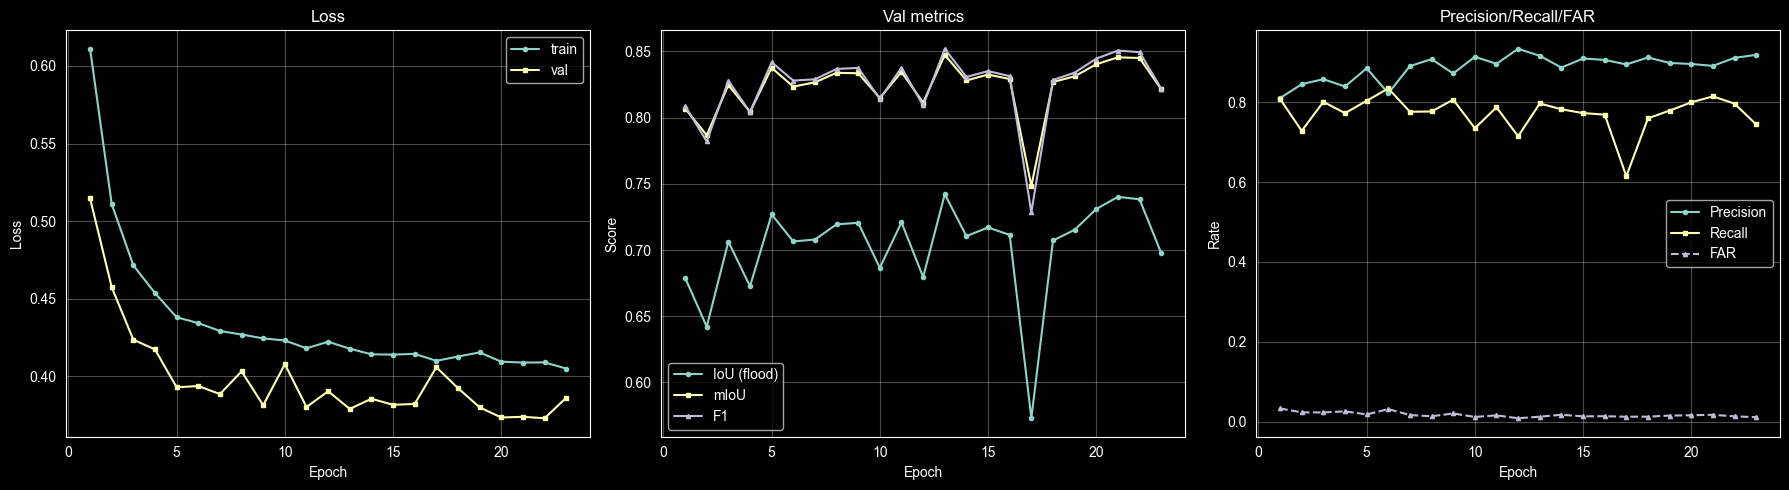

In [19]:
log_df = pd.read_csv(LOG_CSV)
print(log_df.tail(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train', marker='o', ms=3)
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='val',   marker='s', ms=3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['val_iou'],  label='IoU (flood)', marker='o', ms=3)
axes[1].plot(log_df['epoch'], log_df['val_miou'], label='mIoU',        marker='s', ms=3)
axes[1].plot(log_df['epoch'], log_df['val_f1'],   label='F1',          marker='^', ms=3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].set_title('Val metrics')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(log_df['epoch'], log_df['val_precision'], label='Precision', marker='o', ms=3)
axes[2].plot(log_df['epoch'], log_df['val_recall'],    label='Recall',    marker='s', ms=3)
axes[2].plot(log_df['epoch'], log_df['val_far'],       label='FAR',       marker='^', ms=3, linestyle='--')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Rate'); axes[2].set_title('Precision/Recall/FAR')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['output_dir']) / 'figures' / 'learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 19. Tìm ngưỡng dự đoán tối ưu trên tập validation

### Vì sao ngưỡng 0.5 không phải lúc nào cũng tốt nhất?

Mô hình output là **xác suất** $p \in [0, 1]$. Để biến thành nhãn nhị phân, ta áp ngưỡng $\tau$:

$$\hat{y} = \begin{cases} 1 & \text{nếu } p \ge \tau \\ 0 & \text{nếu } p < \tau \end{cases}$$

Ngưỡng mặc định $\tau = 0.5$ chỉ tối ưu nếu:

- Distribution của $p$ đối xứng quanh 0.5.
- Cost của FP và FN bằng nhau.
- Class balance 50/50.

Trong bài toán phân đoạn lũ, các giả định trên đều không thỏa:

- Mô hình train với BCE+Dice trên dataset imbalance (nền nhiều hơn nước) thường output thiên về 0, distribution của $p$ lệch về phía 0.
- Mỗi loại sai có chi phí khác nhau (FP gây lãng phí cứu hộ, FN có thể nguy hiểm).
- Trong nhiều chip, nước chiếm dưới 30% pixel.

Hậu quả: ngưỡng 0.5 thường cho recall thấp (model thận trọng quá). Ta cần tìm $\tau^* < 0.5$ hoặc $\tau^* > 0.5$ tùy đặc tính mô hình.

### Phương pháp tìm ngưỡng

Thuật toán **threshold sweep**:

1. Chia khoảng `[0.20, 0.70]` thành 11 giá trị: `[0.20, 0.25, 0.30, ..., 0.70]`.
2. Với mỗi giá trị $\tau$:
   - Đánh giá mô hình trên **validation set** với ngưỡng đó.
   - Tính F1.
3. Chọn $\tau^*$ có F1 cao nhất.
4. Lưu $\tau^*$ vào `CFG['pred_threshold']` để dùng cho test.

### Vì sao tune trên val, không tune trên test?

Quy tắc vàng của thực nghiệm học máy: **không bao giờ tune hyperparameter (bao gồm ngưỡng) trên test set**. Nếu tune trên test, kết quả test cao giả tạo và không phản ánh khả năng tổng quát hóa thực tế.

Cách đúng:

1. Tune ngưỡng trên val set.
2. Cố định ngưỡng đã chọn.
3. Áp dụng vào test set một lần duy nhất, ghi nhận kết quả.

### Mục tiêu tối ưu: F1

F1 cân bằng Precision và Recall. Nếu muốn nhấn mạnh khác:

- Tối ưu F0.5 nếu ưu tiên Precision (sợ báo nhầm).
- Tối ưu F2 nếu ưu tiên Recall (sợ bỏ sót).

Notebook dùng F1 làm metric mục tiêu (target='f1').

### Kết quả đánh giá test

Sau khi có $\tau^*$, gọi `evaluate_loader(test_loader, threshold=tau)` để tính toàn bộ metric trên test:

- IoU, mIoU, F1, F0.5, Precision, Recall, FAR, Risk.
- Lưu kết quả vào `final_results.csv`.

Đây là **kết quả cuối cùng** dùng để báo cáo.


In [20]:
def tune_threshold_simple(loader, target='f1'):
    '''Tune threshold đơn giản: chọn theo F1 max, không có constraint.'''
    thresholds = [round(x, 2) for x in np.arange(0.20, 0.71, 0.05)]
    rows = []; best = None
    for th in thresholds:
        m = evaluate_loader(loader, threshold=th)
        row = {'threshold': th, **m}
        rows.append(row)
        if best is None or row[target] > best[target]:
            best = row
    print(' th    IoU    mIoU   F1     P      R      FAR')
    for r in rows:
        marker = '*' if r['threshold'] == best['threshold'] else ' '
        print(f"{marker}{r['threshold']:.2f}  {r['iou_flood']:.4f} {r['miou']:.4f} {r['f1']:.4f} "
              f"{r['precision']:.4f} {r['recall']:.4f} {r['far']:.4f}")
    CFG['pred_threshold'] = best['threshold']
    print(f"\nSelected threshold = {CFG['pred_threshold']:.2f} (val {target}={best[target]:.4f})")
    return best, rows

# Load best checkpoint
ckpt = torch.load(BEST_CKPT, map_location=CFG['device'])
model.load_state_dict(ckpt['model'])
print(f"Loaded best (epoch={ckpt['epoch']}, val_iou={ckpt['val_iou']:.4f})\n")

best_th, threshold_rows = tune_threshold_simple(val_loader, target='f1')

# Evaluate test
test_m = evaluate_loader(test_loader, threshold=CFG['pred_threshold'])
print(f"\n========= TEST RESULTS @ threshold {CFG['pred_threshold']:.2f} =========")
for k, v in test_m.items():
    print(f"  {k:12s}: {v:.4f}")

pd.DataFrame([test_m]).to_csv(Path(CFG['output_dir']) / 'final_results.csv', index=False)
pd.DataFrame(threshold_rows).to_csv(Path(CFG['output_dir']) / 'threshold_sweep.csv', index=False)
print("\nĐã lưu final_results.csv và threshold_sweep.csv")


Loaded best (epoch=13, val_iou=0.7422)



eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

...

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

 th    IoU    mIoU   F1     P      R      FAR
 0.20  0.7490 0.8491 0.8565 0.8396 0.8740 0.0296
 0.25  0.7572 0.8548 0.8618 0.8630 0.8607 0.0242
*0.30  0.7586 0.8561 0.8628 0.8777 0.8483 0.0209
 0.35  0.7572 0.8555 0.8618 0.8891 0.8361 0.0185
 0.40  0.7535 0.8536 0.8594 0.8982 0.8239 0.0165
 0.45  0.7486 0.8509 0.8562 0.9067 0.8110 0.0148
 0.50  0.7422 0.8475 0.8520 0.9158 0.7965 0.0130
 0.55  0.7325 0.8421 0.8456 0.9274 0.7770 0.0108
 0.60  0.7152 0.8323 0.8340 0.9377 0.7509 0.0088
 0.65  0.6870 0.8160 0.8144 0.9467 0.7146 0.0071
 0.70  0.6377 0.7877 0.7788 0.9557 0.6571 0.0054

Selected threshold = 0.30 (val f1=0.8628)


eval:   0%|          | 0/9 [00:00<?, ?it/s]


========= TEST RESULTS @ threshold 0.30 =========
  iou_flood   : 0.6302
  iou_bg      : 0.9680
  miou        : 0.7991
  f1          : 0.7731
  f05         : 0.7901
  precision   : 0.8017
  recall      : 0.7465
  far         : 0.0138
  risk        : 323090.0000

Đã lưu final_results.csv và threshold_sweep.csv


## 20. Trực quan hóa dự đoán kèm bản đồ lỗi

### Mục đích

Số liệu metric (IoU, F1) cho biết mô hình tốt đến đâu nhưng không cho biết **tốt/sai ở đâu**. Cell này vẽ trực quan 4 chip test với 6 cột để nhìn rõ hành vi của mô hình.

### Layout 6 cột

| Cột | Hiển thị | Mục đích |
|-----|----------|----------|
| 1   | VV       | Quan sát kênh co-polarization |
| 2   | VH       | Quan sát kênh cross-polarization (nhạy với nước nhất) |
| 3   | Ground truth | Nhãn đối chiếu của chuyên gia |
| 4   | Prediction | Output của mô hình sau threshold |
| 5   | Probability map | Heatmap xác suất từ sigmoid output |
| 6   | Error map | Phân loại lỗi từng pixel |

### Bản đồ xác suất (Probability map)

Hiển thị $p_i = \sigma(z_i)$ cho mỗi pixel, với colormap `magma`:

- Đen: $p \approx 0$ (rất chắc không phải nước).
- Vàng nóng: $p \approx 1$ (rất chắc là nước).
- Tím / đỏ: $p \approx 0.5$ (mơ hồ).

Vùng tím/đỏ là nơi mô hình "phân vân". Một mô hình tốt cần:

- $p$ gần 0 ở vùng background chắc chắn.
- $p$ gần 1 ở vùng water chắc chắn.
- Vùng "phân vân" (0.3-0.7) chỉ tồn tại ở biên water/land, không nên rộng.

### Bản đồ lỗi (Error map)

Phân loại mỗi pixel hợp lệ thành một trong bốn nhóm:

- **TP** (xanh lá `#1aa84d`): cả truth và pred đều là 1 (nước). Mô hình đúng.
- **TN** (xám nhạt `#f0f0f0`): cả truth và pred đều là 0 (nền). Mô hình đúng.
- **FP** (đỏ `#e63946`): pred = 1 nhưng truth = 0. Mô hình **báo nhầm**.
- **FN** (xanh dương `#1f6feb`): pred = 0 nhưng truth = 1. Mô hình **bỏ sót**.

Pixel invalid được hiển thị trắng.

Phía trên mỗi error map ghi số lượng FP và FN của chip đó.

### Cách đọc error map để phân tích lỗi

Một số mẫu lỗi điển hình cần chú ý:

**Cụm FP (đỏ) tập trung ở vùng tối phi nước**

Có thể là:

- Bóng địa hình (terrain shadow) trong vùng núi.
- Mái nhà tối hoặc tòa nhà cao có bóng đổ.
- Vùng đất ướt sau mưa nhưng chưa ngập.

Nguyên nhân: VH thấp ở các vùng này cũng giống nước.

**Cụm FN (xanh dương) tập trung ở biên (contour)**

Có thể là:

- Vùng chuyển tiếp water-land có pixel mix (mixed pixel).
- Sông nhỏ, kênh hẹp dưới ngưỡng phân giải.
- Vùng nước có thực vật nhô lên (vegetation in water).

Nguyên nhân: vùng biên có giá trị backscatter trung gian, mô hình khó quyết.

**FN rải rác (xanh dương) ở các đảo lũ nhỏ**

Mô hình bỏ sót các vùng flood nhỏ, không liên tục. Nguyên nhân: vùng nhỏ có ít pixel hỗ trợ, BCE+Dice không đặc biệt phạt cho việc bỏ sót.

### Cách chọn mẫu để hiển thị

Hàm `find_interesting_samples` lọc các chip có `flood_pct >= 5%` (đủ nước để nhìn rõ kết quả). Nếu chọn ngẫu nhiên, có thể rơi vào chip không có nước, error map khi đó toàn xám không thông tin.


Showing samples: [0, 1, 5, 7]


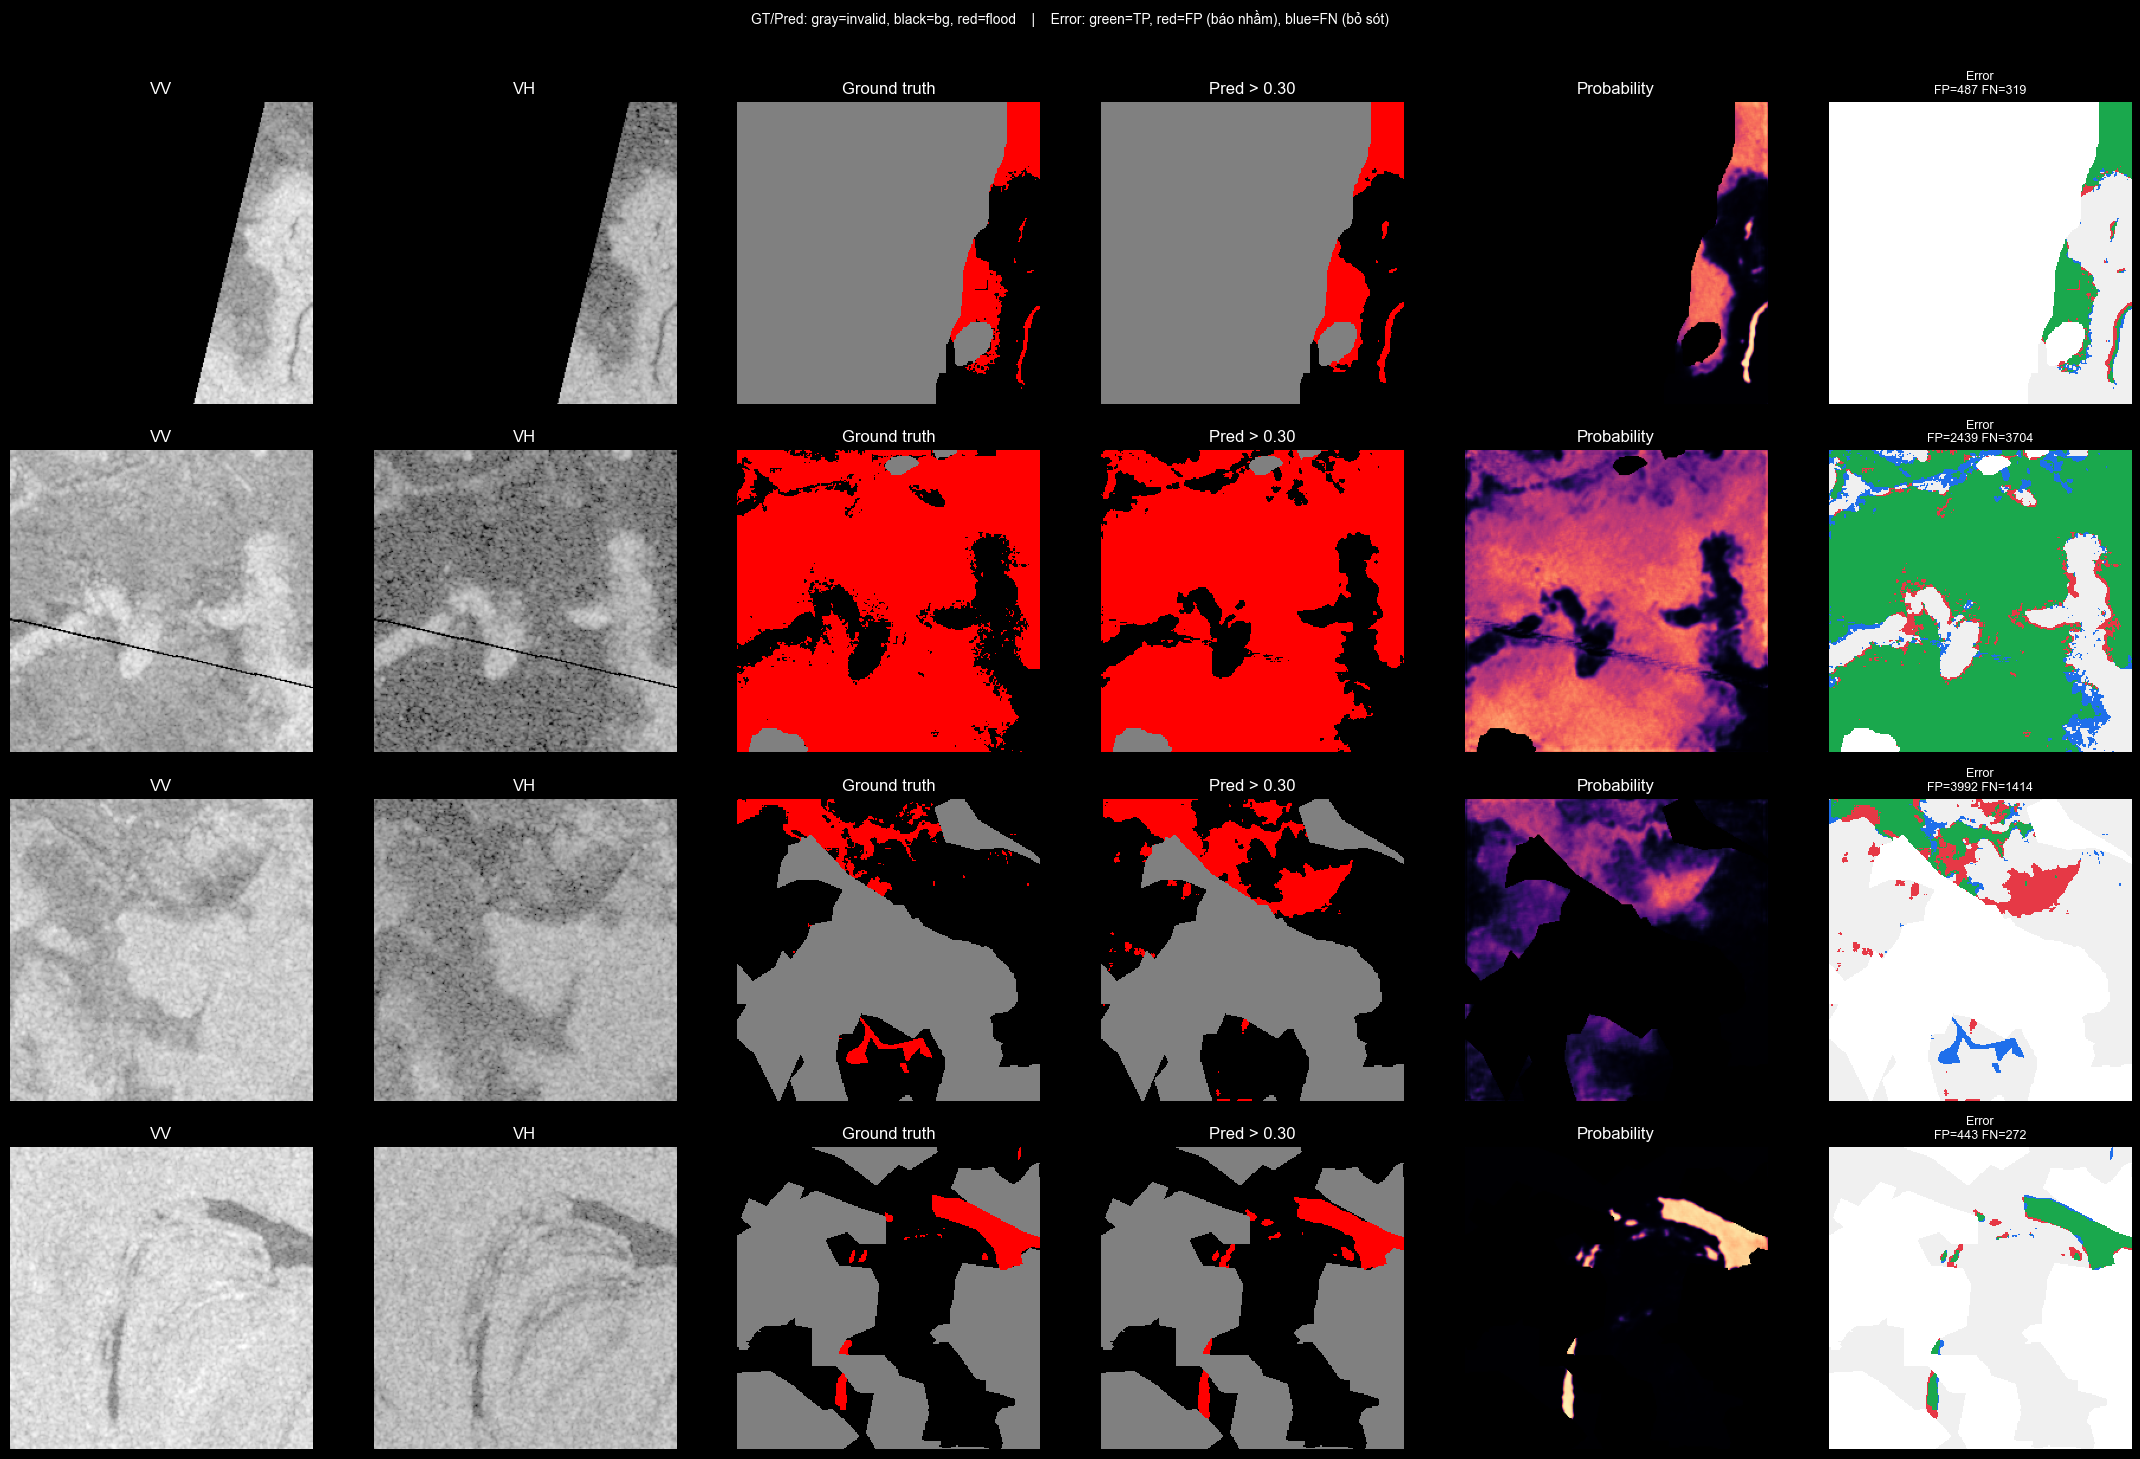

In [21]:
# Sample 4 chip test có flood (% > 5%) để show
def find_interesting_samples(dataset, n=4, min_flood_pct=0.05):
    chosen = []
    for i in range(len(dataset)):
        _, lbl, valid, _ = dataset[i]
        v = valid.numpy().astype(bool)
        if v.sum() == 0: continue
        flood_pct = (lbl.numpy()[v] == 1).mean()
        if flood_pct >= min_flood_pct:
            chosen.append(i)
        if len(chosen) >= n: break
    return chosen if chosen else list(range(min(n, len(dataset))))

sample_ids = find_interesting_samples(ds_test, n=4, min_flood_pct=0.05)
print(f"Showing samples: {sample_ids}")

# Error colormap: 0=invalid (white), 1=TN (lightgray), 2=TP (green), 3=FP (red), 4=FN (blue)
err_cmap = ListedColormap(['white', '#f0f0f0', '#1aa84d', '#e63946', '#1f6feb'])

ckpt = torch.load(BEST_CKPT, map_location=CFG['device'])
model.load_state_dict(ckpt['model']); model.eval()
PRED_THRESHOLD = CFG['pred_threshold']

fig, axes = plt.subplots(len(sample_ids), 6, figsize=(22, 3.6 * len(sample_ids)))
if len(sample_ids) == 1: axes = axes[None, :]

with torch.no_grad():
    for r, idx in enumerate(sample_ids):
        s1, lbl, valid, _ = ds_test[idx]
        s1_b = s1.unsqueeze(0).to(CFG['device'])
        with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
            logits = model(s1_b)
        probs = torch.sigmoid(logits.squeeze().float()).cpu().numpy()
        pred  = (probs > PRED_THRESHOLD).astype(np.int32)
        gt    = lbl.numpy().astype(np.int32)
        vd    = valid.numpy().astype(bool)

        # GT / Pred shifted (+1) for colormap, invalid=0
        gt_show   = gt.copy() + 1;   gt_show[~vd]   = 0
        pred_show = pred.copy() + 1; pred_show[~vd] = 0

        # Probability with NaN for invalid
        prob_show = probs.astype(np.float32); prob_show[~vd] = np.nan

        # Error map: 0=invalid, 1=TN, 2=TP, 3=FP, 4=FN
        err = np.full(gt.shape, 0, dtype=np.int32)
        err[ vd & (gt == 0) & (pred == 0)] = 1   # TN
        err[ vd & (gt == 1) & (pred == 1)] = 2   # TP
        err[ vd & (gt == 0) & (pred == 1)] = 3   # FP (báo nhầm)
        err[ vd & (gt == 1) & (pred == 0)] = 4   # FN (bỏ sót)

        # FP/FN per-sample
        fp_count = (err == 3).sum(); fn_count = (err == 4).sum()
        tp_count = (err == 2).sum(); valid_count = vd.sum()

        axes[r, 0].imshow(s1[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, 0].set_title('VV');  axes[r, 0].axis('off')
        axes[r, 1].imshow(s1[1].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, 1].set_title('VH'); axes[r, 1].axis('off')
        axes[r, 2].imshow(gt_show, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
        axes[r, 2].set_title('Ground truth'); axes[r, 2].axis('off')
        axes[r, 3].imshow(pred_show, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
        axes[r, 3].set_title(f'Pred > {PRED_THRESHOLD:.2f}'); axes[r, 3].axis('off')
        axes[r, 4].imshow(prob_show, cmap='magma', vmin=0, vmax=1)
        axes[r, 4].set_title('Probability'); axes[r, 4].axis('off')
        axes[r, 5].imshow(err, cmap=err_cmap, vmin=0, vmax=4, interpolation='nearest')
        axes[r, 5].set_title(f'Error\nFP={fp_count} FN={fn_count}', fontsize=9)
        axes[r, 5].axis('off')

plt.suptitle('GT/Pred: gray=invalid, black=bg, red=flood    |    '
             'Error: green=TP, red=FP (báo nhầm), blue=FN (bỏ sót)', y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig(Path(CFG['output_dir']) / 'figures' / 'predictions_with_errors.png',
            dpi=120, bbox_inches='tight')
plt.show()


## 21. Phân tích định lượng các loại lỗi

### Mục đích

Sau khi nhìn trực quan ở phần 20, ta cần con số cụ thể để báo cáo:

- Mô hình mắc tổng cộng bao nhiêu lỗi mỗi loại?
- Trong các loại sai, loại nào trội?
- Mô hình "phủ" được bao nhiêu phần trăm flood thật?
- Khi mô hình nói "lũ", xác suất đúng là bao nhiêu?

### Cách tính

Lặp qua toàn bộ test loader, gọi `metric_counts` cho mỗi batch, cộng dồn TP, FP, FN, TN.

Sau đó tính các số liệu chính:

- **Tổng pixel valid** = TP + FP + FN + TN.
- **Tỷ lệ TP, TN, FP, FN** = mỗi count / tổng × 100%.
- **Tỷ lệ FP / FN**: cho biết mô hình thiên về loại sai nào.
- **Coverage = Recall** = TP / (TP + FN). Diễn giải: trong số pixel nước thật, mô hình bắt được bao nhiêu phần trăm.
- **Reliability = Precision** = TP / (TP + FP). Diễn giải: khi mô hình nói nước, đúng bao nhiêu phần trăm.

### Hai khả năng thường gặp

**Khả năng 1: FP > FN (thiên về báo nhầm)**

Mô hình quá "rộng tay" gán nhãn nước. Nguyên nhân thường gặp:

- Bóng địa hình và mái nhà tối có VH thấp tương tự nước.
- Đất ướt sau mưa nhưng chưa ngập.
- Vùng cát/đất khô đặc biệt có texture nhẵn cũng cho VV/VH thấp.

Hệ quả khi triển khai: gây cảnh báo giả, lãng phí nguồn lực cứu hộ.

**Khả năng 2: FN > FP (thiên về bỏ sót)**

Mô hình quá thận trọng. Nguyên nhân thường gặp:

- Hàm Dice + BCE 50/50 không phân biệt FP và FN.
- Threshold = 0.5 quá cao, mô hình chỉ dự đoán nước khi rất chắc.
- Vùng flood nhỏ, fragmentation (kênh hẹp, vũng nhỏ) bị bỏ qua.
- Vùng biên water/land có giá trị trung gian, model "quyết" về nền.

Hệ quả khi triển khai: bỏ sót vùng lũ, có thể nguy hiểm cho cư dân không được cảnh báo.

### Cách phân tích từ code

Cell code tự động in ra thông báo:

```
Tỷ lệ FP / FN : X.XX : 1
→ Baseline THIÊN VỀ BÁO NHẦM (false positive nhiều hơn)
→ Khuyết điểm chính: nhầm urban shadow / dark roofs là nước
```

hoặc ngược lại nếu FN > FP. Đoạn này có thể copy thẳng vào báo cáo.

Ngoài ra, Coverage và Reliability cũng được in. Hai con số này dễ hiểu cho người không chuyên (đặc biệt người làm về phòng chống thiên tai), nên rất phù hợp dùng trong slide báo cáo.


In [22]:
# Đếm tổng FP/FN/TP/TN trên toàn test
counts_all = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
model.eval()
with torch.no_grad():
    for s1, lbl, valid, _ in tqdm(test_loader, desc='analysis'):
        s1 = s1.to(CFG['device']); lbl = lbl.to(CFG['device']); valid = valid.to(CFG['device'])
        with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
            logits = model(s1)
        bc = metric_counts(logits.float(), lbl, valid, threshold=CFG['pred_threshold'])
        for k in counts_all: counts_all[k] += bc[k]

TP = counts_all['TP'].item(); FP = counts_all['FP'].item()
FN = counts_all['FN'].item(); TN = counts_all['TN'].item()
total = TP + FP + FN + TN

print(f"=" * 55)
print(f"PHÂN TÍCH KHUYẾT ĐIỂM TRÊN TEST SET")
print(f"=" * 55)
print(f"Tổng pixel valid : {total:>12,}")
print(f"  TP (đúng lũ)   : {TP:>12,}  ({100*TP/total:.2f}%)")
print(f"  TN (đúng nền)  : {TN:>12,}  ({100*TN/total:.2f}%)")
print(f"  FP (báo nhầm)  : {FP:>12,}  ({100*FP/total:.2f}%)  ← cần giảm")
print(f"  FN (bỏ sót)    : {FN:>12,}  ({100*FN/total:.2f}%)  ← cần giảm")
print()
print(f"Tỷ lệ FP / FN    : {FP/max(FN,1):.2f} : 1")
if FP > FN:
    print(f"  → Baseline THIÊN VỀ BÁO NHẦM (false positive nhiều hơn)")
    print(f"  → Khuyết điểm chính: nhầm urban shadow / dark roofs là nước")
else:
    print(f"  → Baseline THIÊN VỀ BỎ SÓT (false negative nhiều hơn)")
    print(f"  → Khuyết điểm chính: bỏ sót lũ nhỏ, kênh hẹp, biên water-land")
print()
print(f"Coverage (Recall)      : {100*TP/(TP+FN):.2f}%   "
      f"← chỉ bắt được {100*TP/(TP+FN):.0f}% lũ thật")
print(f"Reliability (Precision): {100*TP/(TP+FP):.2f}%   "
      f"← khi báo lũ, đúng {100*TP/(TP+FP):.0f}%")


analysis:   0%|          | 0/9 [00:00<?, ?it/s]

PHÂN TÍCH KHUYẾT ĐIỂM TRÊN TEST SET
Tổng pixel valid :    7,481,332
  TP (đúng lũ)   :      387,334  (5.18%)
  TN (đúng nền)  :    6,866,687  (91.78%)
  FP (báo nhầm)  :       95,779  (1.28%)  ← cần giảm
  FN (bỏ sót)    :      131,532  (1.76%)  ← cần giảm

Tỷ lệ FP / FN    : 0.73 : 1
  → Baseline THIÊN VỀ BỎ SÓT (false negative nhiều hơn)
  → Khuyết điểm chính: bỏ sót lũ nhỏ, kênh hẹp, biên water-land

Coverage (Recall)      : 74.65%   ← chỉ bắt được 75% lũ thật
Reliability (Precision): 80.17%   ← khi báo lũ, đúng 80%


## 22. Kết luận và đánh giá hạn chế của mô hình

### Tóm tắt kết quả

Mô hình U-Net với encoder ResNet34 đã được huấn luyện trên dữ liệu Sen1Floods11 với pipeline:

- Chuẩn hóa giá trị dB về [0, 1] qua phép clip và scale tuyến tính.
- Encoder ResNet34 pretrained ImageNet, decoder U-Net với skip connection.
- Hàm mất mát kết hợp Dice và Binary Cross-Entropy theo tỷ lệ 50/50, có mặt nạ valid để bỏ qua pixel no-data.
- Huấn luyện 50 epoch tối đa với early stopping kích hoạt nếu IoU validation không cải thiện trong 10 epoch.
- Sample weight đồng đều cho mọi mẫu (Hand và Weak đều nhân weight 1.0).
- Ngưỡng quyết định được tinh chỉnh trên tập validation theo F1.

Các chỉ số đánh giá cuối cùng trên test set được lưu trong `outputs_baseline_unet/final_results.csv`.

### Các hạn chế cố hữu của mô hình

Sau khi quan sát các mẫu lỗi ở phần 20 và phân tích định lượng ở phần 21, có thể đúc rút một số hạn chế của mô hình trong cấu hình hiện tại.

**1. Vùng tiếp nhận hữu hạn của encoder tích chập**

ResNet34 có vùng tiếp nhận (receptive field) lý thuyết khoảng 800 pixel ở tầng sâu nhất nhưng vùng tiếp nhận hiệu dụng (effective receptive field) thường nhỏ hơn nhiều, ước lượng khoảng 200-300 pixel. Với chip 256×256 dùng để train, mỗi quyết định cho một pixel chủ yếu dựa trên ngữ cảnh lân cận của pixel đó.

Hệ quả:

- Mô hình khó nắm bắt được pattern toàn cục như "vùng nước chính đang ở nửa Đông của chip" hay "có dòng sông uốn quanh".
- Một pixel tối ở giữa đô thị có thể bị nhầm là nước vì mô hình không "nhìn xa" đủ để hiểu rằng nó nằm trong khu đô thị toàn nhà cao.

**2. Hàm mất mát không phân biệt loại sai**

Tổ hợp Dice + BCE 50/50 phạt cân bằng giữa hai loại sai. Trong bài toán cảnh báo lũ, hai loại sai có chi phí thực tế bất đối xứng:

- Báo nhầm (FP): tốn nguồn lực cứu hộ, gây mệt mỏi cho hệ thống cảnh báo (warning fatigue).
- Bỏ sót (FN): có thể nguy hiểm tính mạng, không cảnh báo người dân vùng ngập.

Hàm mất mát hiện tại không phản ánh được sự khác biệt này. Nếu muốn ưu tiên Recall, có thể cần điều chỉnh trọng số trong loss hoặc dùng hàm mất mát có tham số bất đối xứng.

**3. Nhãn chất lượng cao và nhãn yếu được đối xử như nhau**

Trong cấu hình hiện tại, Hand và Weak đều có sample weight 1.0. Vì Weak labels (4385 chip) đông hơn Hand labels (~250 chip train) gấp 15-20 lần, gradient train bị chi phối bởi Weak. Tuy nhiên Weak có nhiễu (vì sinh tự động từ chỉ số nước Sentinel-2, có thể sai ở vùng cây, vùng cát ướt, bóng).

Hệ quả: mô hình bị "kéo" về phân phối nhãn yếu thay vì phân phối nhãn vàng chuyên gia. Nếu kiểm tra kỹ, một số mẫu lỗi có thể là do mô hình bị ảnh hưởng bởi pattern nhãn yếu mà chuyên gia sẽ gán khác.

**4. Augmentation hạn chế ở mức hình học cơ bản**

Notebook chỉ dùng flip ngang, flip dọc, xoay 90°, và crop ngẫu nhiên. Các augmentation này tăng đa dạng hình học nhưng không tăng đa dạng về:

- Cường độ (intensity variation): mô hình không gặp ảnh có offset calibration khác.
- Nhiễu speckle: speckle thật của SAR có statistic đặc thù mà flip/crop không mô phỏng được.
- Texture cục bộ: không có augmentation phá hủy/thay đổi texture.

Vì vậy, độ robust của mô hình với các ảnh có đặc tính bức xạ khác (chụp ở orbit khác, mùa khác) không được đảm bảo.

**5. Vùng biên water/land được khôi phục kém**

Quan sát trực quan thường thấy:

- Vùng nước rộng (open water) được phân đoạn rất tốt: cả tâm và biên đều đúng.
- Vùng nước nhỏ (sông hẹp, kênh) hay vùng có cây cối nhô lên trong nước (vegetation in flooded area): biên bị mờ, model "tròn hóa" hình dạng thật.

Đây là hạn chế chung của U-Net và các mạng tích chập với segmentation chi tiết: cần signal supervision riêng cho biên hoặc kiến trúc có module xử lý biên chuyên biệt.

**6. Không có cơ chế định lượng độ không chắc chắn**

Mô hình output xác suất sigmoid nhưng đây không phải uncertainty thực sự (xác suất sigmoid của mạng nơ-ron thường over-confident). Khi mô hình "tự tin sai" (dự đoán với $p$ gần 1 nhưng thực tế không phải nước), người dùng không có cách nào biết để cảnh giác.

Trong các ứng dụng cảnh báo, cần biết "vùng nào model chắc, vùng nào model phân vân" để cấp độ ưu tiên xác minh thủ công khác nhau. Mô hình hiện tại không cung cấp signal này.

**7. Khả năng tổng quát hóa sang khu vực mới chưa được kiểm chứng đầy đủ**

Cách chia tập theo nhóm (group split) với Bolivia, Ghana, USA là test set giả lập tình huống "khu vực chưa từng thấy". Tuy nhiên 3 quốc gia này chỉ là một mẫu nhỏ của các loại địa hình toàn cầu. Đối với khu vực có đặc điểm rất khác (ví dụ vùng cực, sa mạc, đảo san hô), kết quả có thể tệ hơn đáng kể.

**8. Hiệu năng phụ thuộc vào pretrained weights của ImageNet**

ResNet34 được khởi tạo từ trọng số train trên ImageNet (ảnh RGB tự nhiên). SAR khác xa ảnh tự nhiên:

- Số kênh khác (2 thay vì 3).
- Dải động khác (dB thay vì 0-255).
- Bản chất vật lý khác (backscatter radar thay vì phản xạ ánh sáng).

Pretrained weights ban đầu chỉ cung cấp một "khởi điểm tốt", phần lớn việc học vẫn diễn ra trong quá trình fine-tune. Tuy nhiên với dữ liệu ít (~250 chip Hand train), khả năng học đặc trưng SAR thực sự bị giới hạn.

### Files xuất ra

Sau khi notebook chạy xong, thư mục `outputs_baseline_unet/` chứa:

- `checkpoints/best.pth`: trọng số mô hình tốt nhất theo val IoU.
- `checkpoints/last.pth`: trọng số mô hình mới nhất (dùng để resume).
- `logs/training_log.csv`: log chi tiết từng epoch (đọc bằng pandas).
- `logs/training_log.txt`: log dạng văn bản tự do.
- `figures/learning_curves.png`: biểu đồ loss và metric theo epoch.
- `figures/predictions_with_errors.png`: minh họa dự đoán kèm error map.
- `final_results.csv`: kết quả test set cuối cùng.
- `threshold_sweep.csv`: kết quả threshold tuning trên val.

Các file này sẵn sàng để đưa vào báo cáo và slide trình bày.
